In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_vaccinations_global.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
df.info()

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

df.head()

Shape: (202840, 17)

Columns:
['country', 'date', 'daily_vaccinations_smoothed', 'daily_people_vaccinated_smoothed', 'daily_people_vaccinated_smoothed_per_hundred', 'daily_vaccinations_smoothed_per_million', 'total_vaccinations_interpolated', 'people_vaccinated_interpolated', 'people_fully_vaccinated_interpolated', 'total_boosters_interpolated', 'total_vaccinations_no_boosters_interpolated', 'rolling_vaccinations_6m', 'rolling_vaccinations_6m_per_hundred', 'rolling_vaccinations_9m', 'rolling_vaccinations_9m_per_hundred', 'rolling_vaccinations_12m', 'rolling_vaccinations_12m_per_hundred']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202840 entries, 0 to 202839
Data columns (total 17 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   country                                       202840 non-null  object 
 1   date                                          202840 n

,country,date,daily_vaccinations_smoothed,daily_people_vaccinated_smoothed,daily_people_vaccinated_smoothed_per_hundred,daily_vaccinations_smoothed_per_million,total_vaccinations_interpolated,people_vaccinated_interpolated,people_fully_vaccinated_interpolated,total_boosters_interpolated,total_vaccinations_no_boosters_interpolated,rolling_vaccinations_6m,rolling_vaccinations_6m_per_hundred,rolling_vaccinations_9m,rolling_vaccinations_9m_per_hundred,rolling_vaccinations_12m,rolling_vaccinations_12m_per_hundred
0,Afghanistan,2021-02-23,1366.666667,1366.666667,0.003368,33.679288,1366.666667,1366.666667,55624.0,0.0,1366.666667,1366.666667,0.003368,1366.666667,0.003368,1366.666667,0.003368
1,Afghanistan,2021-02-24,1366.666667,1366.666667,0.003368,33.679288,2733.333333,2733.333333,55624.0,0.0,2733.333333,2733.333333,0.006736,2733.333333,0.006736,2733.333333,0.006736
2,Afghanistan,2021-02-25,1366.666667,1366.666667,0.003368,33.679288,4100.000000,4100.000000,55624.0,0.0,4100.000000,4100.000000,0.010104,4100.000000,0.010104,4100.000000,0.010104
3,Afghanistan,2021-02-26,1366.666667,1366.666667,0.003368,33.679288,5466.666667,5466.666667,55624.0,0.0,5466.666667,5466.666667,0.013472,5466.666667,0.013472,5466.666667,0.013472
4,Afghanistan,2021-02-27,1366.666667,1366.666667,0.003368,33.679288,6833.333333,6833.333333,55624.0,0.0,6833.333333,6833.333333,0.016840,6833.333333,0.016840,6833.333333,0.016840


In [3]:
keep_cols = [
    "country",
    "date",
    "daily_vaccinations_smoothed",
    "daily_people_vaccinated_smoothed",
    "people_vaccinated_interpolated",
    "people_fully_vaccinated_interpolated",
    "total_boosters_interpolated"
]

main_df = df[[col for col in keep_cols if col in df.columns]].copy()
main_df["date"] = pd.to_datetime(main_df["date"])
main_df = main_df.sort_values(["country", "date"]).reset_index(drop=True)

print(main_df.shape)
main_df.head()

(202840, 7)


,country,date,daily_vaccinations_smoothed,daily_people_vaccinated_smoothed,people_vaccinated_interpolated,people_fully_vaccinated_interpolated,total_boosters_interpolated
0,Afghanistan,2021-02-23,1366.666667,1366.666667,1366.666667,55624.0,0.0
1,Afghanistan,2021-02-24,1366.666667,1366.666667,2733.333333,55624.0,0.0
2,Afghanistan,2021-02-25,1366.666667,1366.666667,4100.000000,55624.0,0.0
3,Afghanistan,2021-02-26,1366.666667,1366.666667,5466.666667,55624.0,0.0
4,Afghanistan,2021-02-27,1366.666667,1366.666667,6833.333333,55624.0,0.0


In [4]:
countries = sorted(main_df["country"].dropna().unique().tolist())
print("国家数量：", len(countries))
print(countries[:30])

国家数量： 229
['Afghanistan', 'Africa', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Asia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia', 'Bonaire Sint Eustatius and Saba', 'Bosnia and Herzegovina', 'Botswana', 'Brazil']


In [5]:
selected_countries = ["United States", "China", "Brazil", "Japan", "Germany"]
subset = main_df[main_df["country"].isin(selected_countries)].copy()

print(subset["country"].unique())
print(subset.shape)
subset.head()

['Brazil' 'China' 'Germany' 'Japan' 'United States']
(4947, 7)


,country,date,daily_vaccinations_smoothed,daily_people_vaccinated_smoothed,people_vaccinated_interpolated,people_fully_vaccinated_interpolated,total_boosters_interpolated
26042,Brazil,2021-01-18,997.000000,997.000000,1109.0,0.0,0.0
26043,Brazil,2021-01-19,6707.500000,6707.500000,13527.0,0.0,0.0
26044,Brazil,2021-01-20,35237.333333,35237.333333,105824.0,0.0,0.0
26045,Brazil,2021-01-21,48396.750000,48396.750000,193699.0,0.0,0.0
26046,Brazil,2021-01-22,92431.400000,92431.400000,462269.0,0.0,0.0


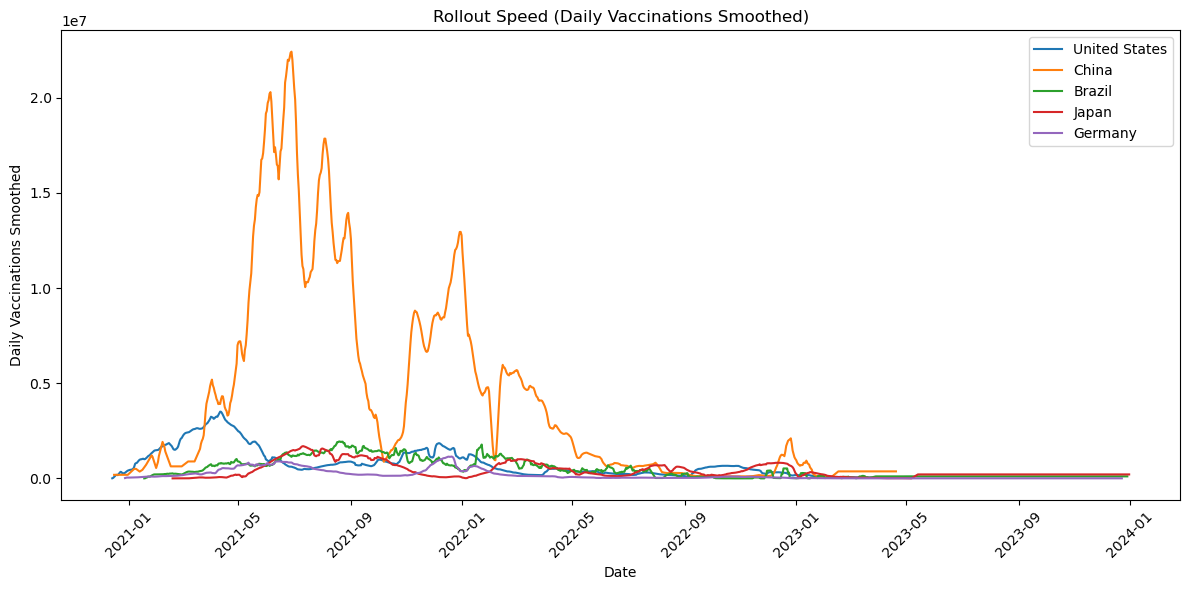

In [6]:
plt.figure(figsize=(12, 6))

for country in selected_countries:
    temp = subset[subset["country"] == country]
    plt.plot(temp["date"], temp["daily_vaccinations_smoothed"], label=country)

plt.title("Rollout Speed (Daily Vaccinations Smoothed)")
plt.xlabel("Date")
plt.ylabel("Daily Vaccinations Smoothed")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

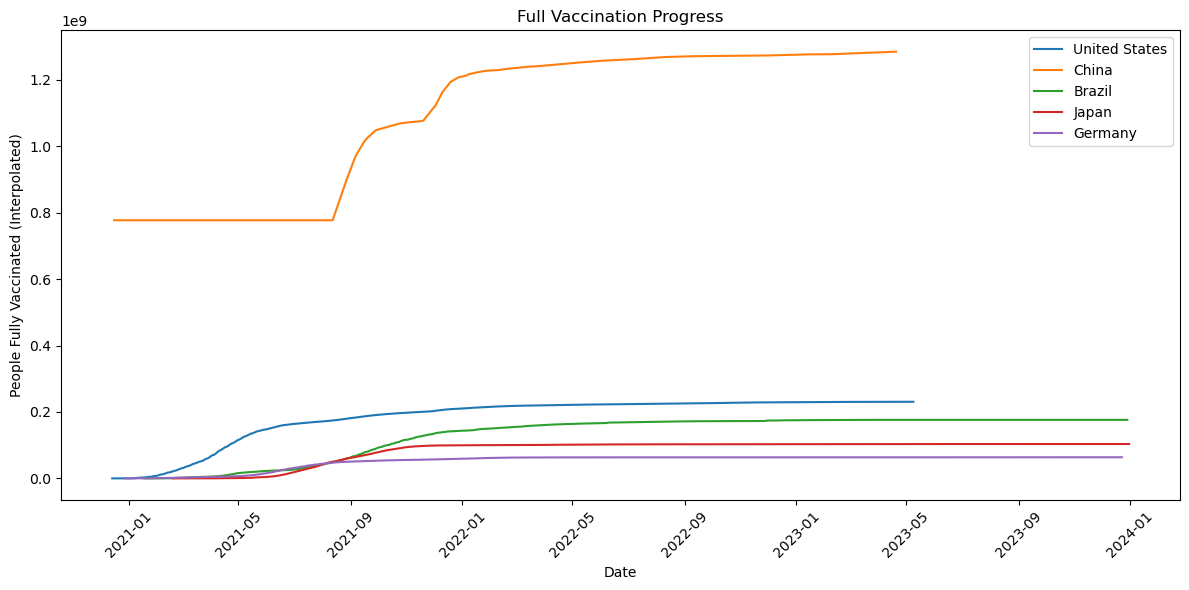

In [7]:
plt.figure(figsize=(12, 6))

for country in selected_countries:
    temp = subset[subset["country"] == country]
    plt.plot(temp["date"], temp["people_fully_vaccinated_interpolated"], label=country)

plt.title("Full Vaccination Progress")
plt.xlabel("Date")
plt.ylabel("People Fully Vaccinated (Interpolated)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

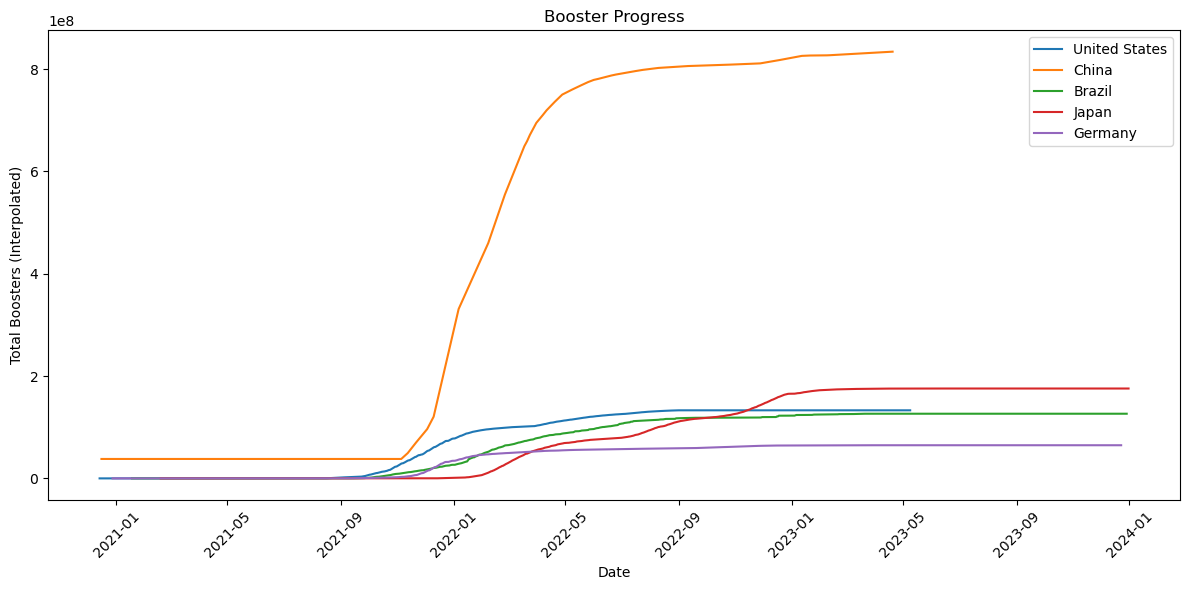

In [8]:
plt.figure(figsize=(12, 6))

for country in selected_countries:
    temp = subset[subset["country"] == country]
    plt.plot(temp["date"], temp["total_boosters_interpolated"], label=country)

plt.title("Booster Progress")
plt.xlabel("Date")
plt.ylabel("Total Boosters (Interpolated)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
summary = []

for country in selected_countries:
    temp = subset[subset["country"] == country].sort_values("date")
    last_row = temp.iloc[-1]
    
    summary.append({
        "country": country,
        "latest_date": last_row["date"],
        "latest_daily_vaccinations_smoothed": last_row["daily_vaccinations_smoothed"],
        "latest_people_vaccinated": last_row["people_vaccinated_interpolated"],
        "latest_people_fully_vaccinated": last_row["people_fully_vaccinated_interpolated"],
        "latest_total_boosters": last_row["total_boosters_interpolated"]
    })

summary_df = pd.DataFrame(summary)
summary_df

,country,latest_date,latest_daily_vaccinations_smoothed,latest_people_vaccinated,latest_people_fully_vaccinated,latest_total_boosters
0,United States,2023-05-09,62309.285714,2.702272e+08,2.306373e+08,133062763.0
1,China,2023-04-20,368624.528571,1.318027e+09,1.284480e+09,834060133.0
2,Brazil,2023-12-29,105676.134752,1.896434e+08,1.761642e+08,126388587.0
3,Japan,2023-12-31,208440.613445,1.047401e+08,1.034552e+08,175662262.0
4,Germany,2023-12-23,3923.034615,6.487630e+07,6.356614e+07,64791434.0


In [10]:
start_dates = []

for country in selected_countries:
    temp = subset[subset["country"] == country].sort_values("date")
    first_vacc_date = temp[temp["people_vaccinated_interpolated"] > 0]["date"].min()
    start_dates.append({
        "country": country,
        "first_vaccination_date": first_vacc_date
    })

start_dates_df = pd.DataFrame(start_dates)
start_dates_df

,country,first_vaccination_date
0,United States,2020-12-14
1,China,2020-12-16
2,Brazil,2021-01-18
3,Japan,2021-02-18
4,Germany,2020-12-28


In [12]:
aligned_rows = []

for country in selected_countries:
    temp = subset[subset["country"] == country].sort_values("date").copy()

    first_vacc_date = temp[temp["people_vaccinated_interpolated"] > 0]["date"].min()
    temp = temp[temp["date"] >= first_vacc_date].copy()
    temp["rollout_day"] = (temp["date"] - first_vacc_date).dt.days

    aligned_rows.append(temp)

aligned_df = pd.concat(aligned_rows, ignore_index=True)
aligned_df.head()

,country,date,daily_vaccinations_smoothed,daily_people_vaccinated_smoothed,people_vaccinated_interpolated,people_fully_vaccinated_interpolated,total_boosters_interpolated,rollout_day
0,United States,2020-12-14,4848.000000,4648.000000,41465.0,9833.0,0.0,0
1,United States,2020-12-15,26366.500000,25533.000000,87883.0,10161.0,0.0,1
2,United States,2020-12-16,70961.333333,68860.333333,243398.0,10679.0,0.0,2
3,United States,2020-12-17,122030.500000,118706.750000,511644.0,11505.0,0.0,3
4,United States,2020-12-18,181834.000000,177281.000000,923222.0,12831.0,0.0,4


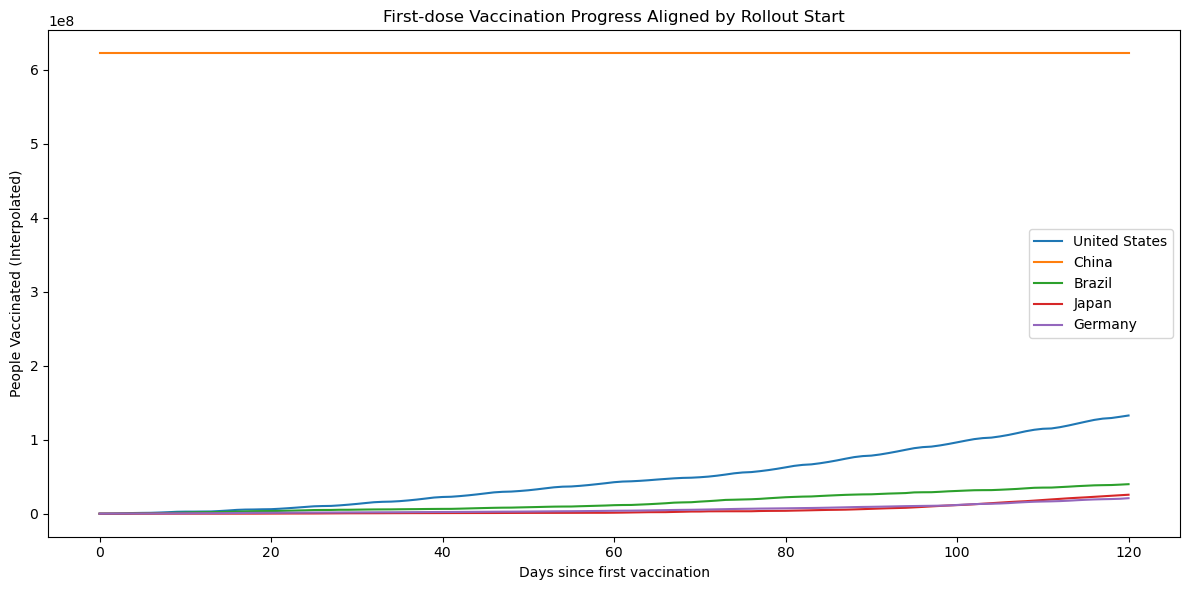

In [13]:
plt.figure(figsize=(12, 6))

for country in selected_countries:
    temp = aligned_df[aligned_df["country"] == country]
    temp = temp[temp["rollout_day"] <= 120]
    plt.plot(temp["rollout_day"], temp["people_vaccinated_interpolated"], label=country)

plt.title("First-dose Vaccination Progress Aligned by Rollout Start")
plt.xlabel("Days since first vaccination")
plt.ylabel("People Vaccinated (Interpolated)")
plt.legend()
plt.tight_layout()
plt.show()

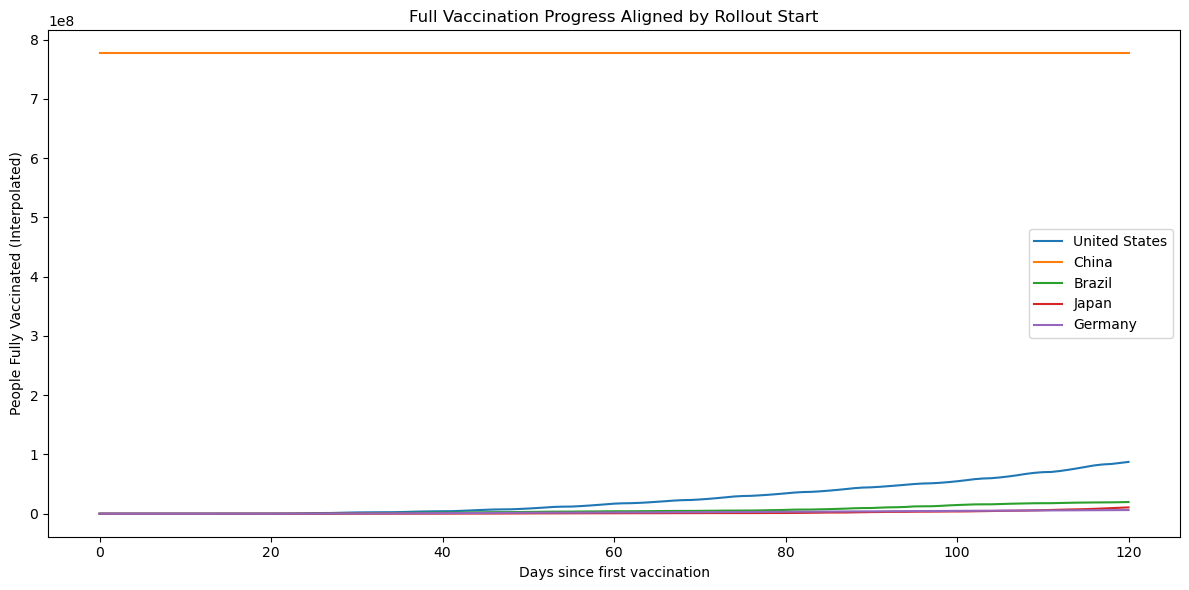

In [14]:
plt.figure(figsize=(12, 6))

for country in selected_countries:
    temp = aligned_df[aligned_df["country"] == country]
    temp = temp[temp["rollout_day"] <= 120]
    plt.plot(temp["rollout_day"], temp["people_fully_vaccinated_interpolated"], label=country)

plt.title("Full Vaccination Progress Aligned by Rollout Start")
plt.xlabel("Days since first vaccination")
plt.ylabel("People Fully Vaccinated (Interpolated)")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
import numpy as np

bar_df = feature_df[["country", "vaccinated_day_30", "vaccinated_day_60", "vaccinated_day_80"]].copy()
bar_df = bar_df.set_index("country")

x = np.arange(len(bar_df.index))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, bar_df["vaccinated_day_30"], width, label="Day 30")
plt.bar(x,         bar_df["vaccinated_day_60"], width, label="Day 60")
plt.bar(x + width, bar_df["vaccinated_day_80"], width, label="Day 80")

plt.xticks(x, bar_df.index, rotation=15)
plt.ylabel("People Vaccinated (Interpolated)")
plt.title("Vaccination Progress at Day 30 / 60 / 80")
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'feature_df' is not defined

In [16]:
[c for c in df.columns if "vacc" in c.lower() or "booster" in c.lower() or "hundred" in c.lower()]

['daily_vaccinations_smoothed',
 'daily_people_vaccinated_smoothed',
 'daily_people_vaccinated_smoothed_per_hundred',
 'daily_vaccinations_smoothed_per_million',
 'total_vaccinations_interpolated',
 'people_vaccinated_interpolated',
 'people_fully_vaccinated_interpolated',
 'total_boosters_interpolated',
 'total_vaccinations_no_boosters_interpolated',
 'rolling_vaccinations_6m',
 'rolling_vaccinations_6m_per_hundred',
 'rolling_vaccinations_9m',
 'rolling_vaccinations_9m_per_hundred',
 'rolling_vaccinations_12m',
 'rolling_vaccinations_12m_per_hundred']

In [17]:
aligned_df = aligned_df.copy()

# 计算每个国家的“最终值”
final_values = aligned_df.groupby("country").agg({
    "people_vaccinated_interpolated": "max",
    "people_fully_vaccinated_interpolated": "max",
    "total_boosters_interpolated": "max"
}).rename(columns={
    "people_vaccinated_interpolated": "final_people_vaccinated",
    "people_fully_vaccinated_interpolated": "final_people_fully_vaccinated",
    "total_boosters_interpolated": "final_total_boosters"
}).reset_index()

# 合并回 aligned_df
aligned_df = aligned_df.merge(final_values, on="country", how="left")

# 构造 0~1 的进度比例
aligned_df["vaccinated_progress_ratio"] = (
    aligned_df["people_vaccinated_interpolated"] / aligned_df["final_people_vaccinated"]
)

aligned_df["fully_vaccinated_progress_ratio"] = (
    aligned_df["people_fully_vaccinated_interpolated"] / aligned_df["final_people_fully_vaccinated"]
)

aligned_df["booster_progress_ratio"] = (
    aligned_df["total_boosters_interpolated"] / aligned_df["final_total_boosters"]
)

aligned_df.head()

,country,date,daily_vaccinations_smoothed,daily_people_vaccinated_smoothed,people_vaccinated_interpolated,people_fully_vaccinated_interpolated,total_boosters_interpolated,rollout_day,final_people_vaccinated,final_people_fully_vaccinated,final_total_boosters,vaccinated_progress_ratio,fully_vaccinated_progress_ratio,booster_progress_ratio
0,United States,2020-12-14,4848.000000,4648.000000,41465.0,9833.0,0.0,0,270227181.0,230637348.0,133062763.0,0.000153,0.000043,0.0
1,United States,2020-12-15,26366.500000,25533.000000,87883.0,10161.0,0.0,1,270227181.0,230637348.0,133062763.0,0.000325,0.000044,0.0
2,United States,2020-12-16,70961.333333,68860.333333,243398.0,10679.0,0.0,2,270227181.0,230637348.0,133062763.0,0.000901,0.000046,0.0
3,United States,2020-12-17,122030.500000,118706.750000,511644.0,11505.0,0.0,3,270227181.0,230637348.0,133062763.0,0.001893,0.000050,0.0
4,United States,2020-12-18,181834.000000,177281.000000,923222.0,12831.0,0.0,4,270227181.0,230637348.0,133062763.0,0.003416,0.000056,0.0


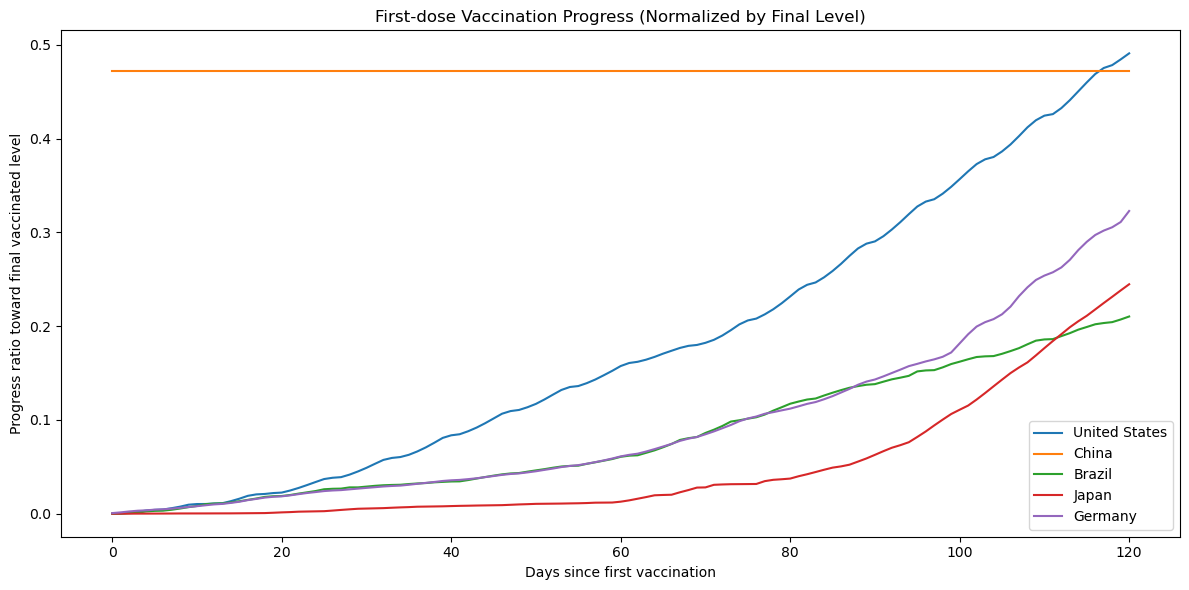

In [18]:
plt.figure(figsize=(12, 6))

for country in selected_countries:
    temp = aligned_df[aligned_df["country"] == country].copy()
    temp = temp[temp["rollout_day"] <= 120]
    plt.plot(temp["rollout_day"], temp["vaccinated_progress_ratio"], label=country)

plt.title("First-dose Vaccination Progress (Normalized by Final Level)")
plt.xlabel("Days since first vaccination")
plt.ylabel("Progress ratio toward final vaccinated level")
plt.legend()
plt.tight_layout()
plt.show()

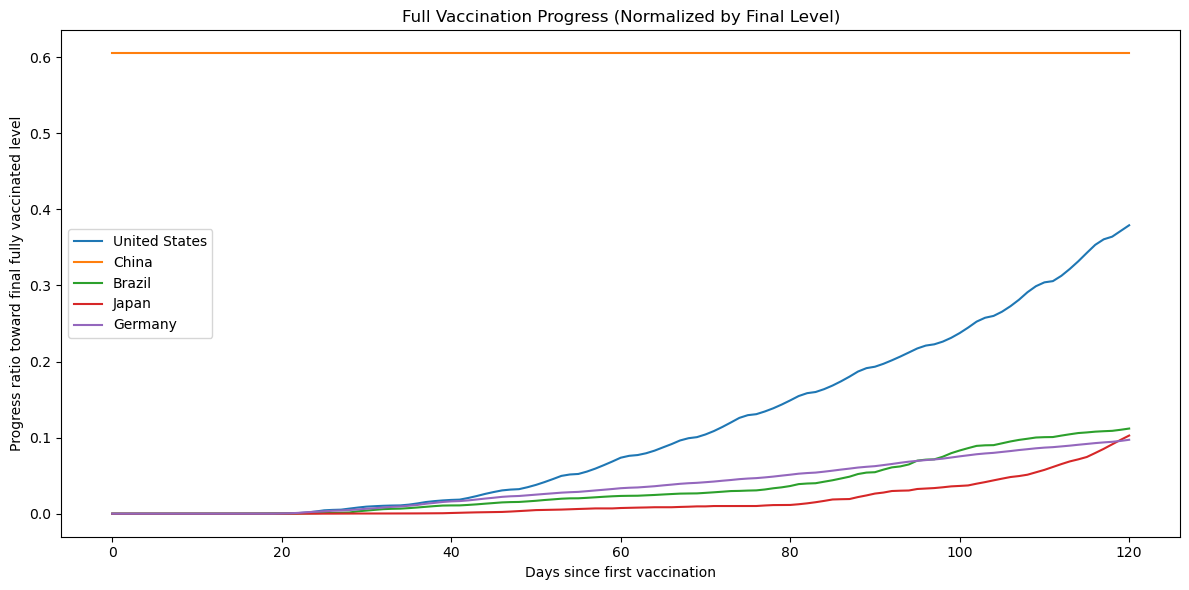

In [19]:
plt.figure(figsize=(12, 6))

for country in selected_countries:
    temp = aligned_df[aligned_df["country"] == country].copy()
    temp = temp[temp["rollout_day"] <= 120]
    plt.plot(temp["rollout_day"], temp["fully_vaccinated_progress_ratio"], label=country)

plt.title("Full Vaccination Progress (Normalized by Final Level)")
plt.xlabel("Days since first vaccination")
plt.ylabel("Progress ratio toward final fully vaccinated level")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
import numpy as np

bar_df = feature_df[[
    "country",
    "vaccinated_day_30_ratio",
    "vaccinated_day_60_ratio",
    "vaccinated_day_80_ratio"
]].copy()

bar_df = bar_df.set_index("country")

x = np.arange(len(bar_df.index))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, bar_df["vaccinated_day_30_ratio"], width, label="Day 30")
plt.bar(x,         bar_df["vaccinated_day_60_ratio"], width, label="Day 60")
plt.bar(x + width, bar_df["vaccinated_day_80_ratio"], width, label="Day 80")

plt.xticks(x, bar_df.index, rotation=15)
plt.ylabel("Progress ratio toward final vaccinated level")
plt.title("Vaccination Progress at Day 30 / 60 / 80")
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'feature_df' is not defined

In [21]:
china_check = aligned_df[aligned_df["country"] == "China"][
    [
        "date",
        "rollout_day",
        "people_vaccinated_interpolated",
        "final_people_vaccinated",
        "vaccinated_progress_ratio",
        "daily_people_vaccinated_smoothed",
        "daily_people_vaccinated_smoothed_per_hundred"
    ]
].copy()

china_120 = china_check[china_check["rollout_day"] <= 120].copy()

print(china_120.head(15))
print(china_120.tail(15))

KeyError: "['daily_people_vaccinated_smoothed_per_hundred'] not in index"

In [22]:
print(main_df.columns.tolist())
print(aligned_df.columns.tolist())

['country', 'date', 'daily_vaccinations_smoothed', 'daily_people_vaccinated_smoothed', 'people_vaccinated_interpolated', 'people_fully_vaccinated_interpolated', 'total_boosters_interpolated']
['country', 'date', 'daily_vaccinations_smoothed', 'daily_people_vaccinated_smoothed', 'people_vaccinated_interpolated', 'people_fully_vaccinated_interpolated', 'total_boosters_interpolated', 'rollout_day', 'final_people_vaccinated', 'final_people_fully_vaccinated', 'final_total_boosters', 'vaccinated_progress_ratio', 'fully_vaccinated_progress_ratio', 'booster_progress_ratio']


In [23]:
keep_cols = [
    "country",
    "date",
    "daily_vaccinations_smoothed",
    "daily_people_vaccinated_smoothed",
    "daily_people_vaccinated_smoothed_per_hundred",
    "people_vaccinated_interpolated",
    "people_fully_vaccinated_interpolated",
    "total_boosters_interpolated"
]

main_df = df[[col for col in keep_cols if col in df.columns]].copy()
main_df["date"] = pd.to_datetime(main_df["date"])
main_df = main_df.sort_values(["country", "date"]).reset_index(drop=True)

print(main_df.columns.tolist())

['country', 'date', 'daily_vaccinations_smoothed', 'daily_people_vaccinated_smoothed', 'daily_people_vaccinated_smoothed_per_hundred', 'people_vaccinated_interpolated', 'people_fully_vaccinated_interpolated', 'total_boosters_interpolated']


In [24]:
subset = main_df[main_df["country"].isin(selected_countries)].copy()
print(subset.columns.tolist())

['country', 'date', 'daily_vaccinations_smoothed', 'daily_people_vaccinated_smoothed', 'daily_people_vaccinated_smoothed_per_hundred', 'people_vaccinated_interpolated', 'people_fully_vaccinated_interpolated', 'total_boosters_interpolated']


In [25]:
aligned_rows = []

for country in selected_countries:
    temp = subset[subset["country"] == country].sort_values("date").copy()

    first_vacc_date = temp[temp["people_vaccinated_interpolated"] > 0]["date"].min()
    temp = temp[temp["date"] >= first_vacc_date].copy()
    temp["rollout_day"] = (temp["date"] - first_vacc_date).dt.days

    aligned_rows.append(temp)

aligned_df = pd.concat(aligned_rows, ignore_index=True)

print(aligned_df.columns.tolist())

['country', 'date', 'daily_vaccinations_smoothed', 'daily_people_vaccinated_smoothed', 'daily_people_vaccinated_smoothed_per_hundred', 'people_vaccinated_interpolated', 'people_fully_vaccinated_interpolated', 'total_boosters_interpolated', 'rollout_day']


In [26]:
china_check = aligned_df[aligned_df["country"] == "China"][
    [
        "date",
        "rollout_day",
        "people_vaccinated_interpolated",
        "daily_people_vaccinated_smoothed",
        "daily_people_vaccinated_smoothed_per_hundred"
    ]
].copy()

china_120 = china_check[china_check["rollout_day"] <= 120].copy()

print(china_120.head(15))
print(china_120.tail(15))

          date  rollout_day  people_vaccinated_interpolated  \
877 2020-12-16            0                     622000000.0   
878 2020-12-17            1                     622000000.0   
879 2020-12-18            2                     622000000.0   
880 2020-12-19            3                     622000000.0   
881 2020-12-20            4                     622000000.0   
882 2020-12-21            5                     622000000.0   
883 2020-12-22            6                     622000000.0   
884 2020-12-23            7                     622000000.0   
885 2020-12-24            8                     622000000.0   
886 2020-12-25            9                     622000000.0   
887 2020-12-26           10                     622000000.0   
888 2020-12-27           11                     622000000.0   
889 2020-12-28           12                     622000000.0   
890 2020-12-29           13                     622000000.0   
891 2020-12-30           14                     6220000

In [27]:
selected_countries_main = ["United States", "Germany", "Brazil", "Japan"]

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

keep_cols = [
    "country",
    "date",
    "daily_vaccinations_smoothed",
    "daily_people_vaccinated_smoothed",
    "daily_people_vaccinated_smoothed_per_hundred",
    "people_vaccinated_interpolated",
    "people_fully_vaccinated_interpolated",
    "total_boosters_interpolated"
]

main_df = df[[col for col in keep_cols if col in df.columns]].copy()
main_df["date"] = pd.to_datetime(main_df["date"])
main_df = main_df.sort_values(["country", "date"]).reset_index(drop=True)

print(main_df.columns.tolist())
main_df.head()

['country', 'date', 'daily_vaccinations_smoothed', 'daily_people_vaccinated_smoothed', 'daily_people_vaccinated_smoothed_per_hundred', 'people_vaccinated_interpolated', 'people_fully_vaccinated_interpolated', 'total_boosters_interpolated']


,country,date,daily_vaccinations_smoothed,daily_people_vaccinated_smoothed,daily_people_vaccinated_smoothed_per_hundred,people_vaccinated_interpolated,people_fully_vaccinated_interpolated,total_boosters_interpolated
0,Afghanistan,2021-02-23,1366.666667,1366.666667,0.003368,1366.666667,55624.0,0.0
1,Afghanistan,2021-02-24,1366.666667,1366.666667,0.003368,2733.333333,55624.0,0.0
2,Afghanistan,2021-02-25,1366.666667,1366.666667,0.003368,4100.000000,55624.0,0.0
3,Afghanistan,2021-02-26,1366.666667,1366.666667,0.003368,5466.666667,55624.0,0.0
4,Afghanistan,2021-02-27,1366.666667,1366.666667,0.003368,6833.333333,55624.0,0.0


In [29]:
subset = main_df[main_df["country"].isin(selected_countries_main)].copy()
print(subset["country"].unique())
subset.head()

['Brazil' 'Germany' 'Japan' 'United States']


,country,date,daily_vaccinations_smoothed,daily_people_vaccinated_smoothed,daily_people_vaccinated_smoothed_per_hundred,people_vaccinated_interpolated,people_fully_vaccinated_interpolated,total_boosters_interpolated
26042,Brazil,2021-01-18,997.000000,997.000000,0.000474,1109.0,0.0,0.0
26043,Brazil,2021-01-19,6707.500000,6707.500000,0.003189,13527.0,0.0,0.0
26044,Brazil,2021-01-20,35237.333333,35237.333333,0.016755,105824.0,0.0,0.0
26045,Brazil,2021-01-21,48396.750000,48396.750000,0.023012,193699.0,0.0,0.0
26046,Brazil,2021-01-22,92431.400000,92431.400000,0.043951,462269.0,0.0,0.0


In [30]:
aligned_rows = []

for country in selected_countries_main:
    temp = subset[subset["country"] == country].sort_values("date").copy()

    temp["vaccinated_diff"] = temp["people_vaccinated_interpolated"].diff()

    first_change_date = temp[temp["vaccinated_diff"] > 0]["date"].min()

    temp = temp[temp["date"] >= first_change_date].copy()
    temp["rollout_day"] = (temp["date"] - first_change_date).dt.days

    aligned_rows.append(temp)

aligned_df = pd.concat(aligned_rows, ignore_index=True)

print(aligned_df["country"].unique())
aligned_df.head()

['United States' 'Germany' 'Brazil' 'Japan']


,country,date,daily_vaccinations_smoothed,daily_people_vaccinated_smoothed,daily_people_vaccinated_smoothed_per_hundred,people_vaccinated_interpolated,people_fully_vaccinated_interpolated,total_boosters_interpolated,vaccinated_diff,rollout_day
0,United States,2020-12-15,26366.500000,25533.000000,0.007476,87883.0,10161.0,0.0,46418.0,0
1,United States,2020-12-16,70961.333333,68860.333333,0.020162,243398.0,10679.0,0.0,155515.0,1
2,United States,2020-12-17,122030.500000,118706.750000,0.034757,511644.0,11505.0,0.0,268246.0,2
3,United States,2020-12-18,181834.000000,177281.000000,0.051907,923222.0,12831.0,0.0,411578.0,3
4,United States,2020-12-19,182230.500000,177700.500000,0.052030,1103020.0,13990.0,0.0,179798.0,4


In [31]:
start_dates = []

for country in selected_countries_main:
    temp = aligned_df[aligned_df["country"] == country].sort_values("rollout_day")
    first_date = temp["date"].min()

    start_dates.append({
        "country": country,
        "rollout_start_date": first_date
    })

start_dates_df = pd.DataFrame(start_dates)
start_dates_df

,country,rollout_start_date
0,United States,2020-12-15
1,Germany,2020-12-29
2,Brazil,2021-01-19
3,Japan,2021-02-19


In [32]:
final_values = aligned_df.groupby("country").agg({
    "people_vaccinated_interpolated": "max",
    "people_fully_vaccinated_interpolated": "max",
    "total_boosters_interpolated": "max"
}).rename(columns={
    "people_vaccinated_interpolated": "final_people_vaccinated",
    "people_fully_vaccinated_interpolated": "final_people_fully_vaccinated",
    "total_boosters_interpolated": "final_total_boosters"
}).reset_index()

aligned_df = aligned_df.merge(final_values, on="country", how="left")

aligned_df["vaccinated_progress_ratio"] = (
    aligned_df["people_vaccinated_interpolated"] / aligned_df["final_people_vaccinated"]
)

aligned_df["fully_vaccinated_progress_ratio"] = (
    aligned_df["people_fully_vaccinated_interpolated"] / aligned_df["final_people_fully_vaccinated"]
)

aligned_df["booster_progress_ratio"] = (
    aligned_df["total_boosters_interpolated"] / aligned_df["final_total_boosters"]
)

aligned_df.head()

,country,date,daily_vaccinations_smoothed,daily_people_vaccinated_smoothed,daily_people_vaccinated_smoothed_per_hundred,people_vaccinated_interpolated,people_fully_vaccinated_interpolated,total_boosters_interpolated,vaccinated_diff,rollout_day,final_people_vaccinated,final_people_fully_vaccinated,final_total_boosters,vaccinated_progress_ratio,fully_vaccinated_progress_ratio,booster_progress_ratio
0,United States,2020-12-15,26366.500000,25533.000000,0.007476,87883.0,10161.0,0.0,46418.0,0,270227181.0,230637348.0,133062763.0,0.000325,0.000044,0.0
1,United States,2020-12-16,70961.333333,68860.333333,0.020162,243398.0,10679.0,0.0,155515.0,1,270227181.0,230637348.0,133062763.0,0.000901,0.000046,0.0
2,United States,2020-12-17,122030.500000,118706.750000,0.034757,511644.0,11505.0,0.0,268246.0,2,270227181.0,230637348.0,133062763.0,0.001893,0.000050,0.0
3,United States,2020-12-18,181834.000000,177281.000000,0.051907,923222.0,12831.0,0.0,411578.0,3,270227181.0,230637348.0,133062763.0,0.003416,0.000056,0.0
4,United States,2020-12-19,182230.500000,177700.500000,0.052030,1103020.0,13990.0,0.0,179798.0,4,270227181.0,230637348.0,133062763.0,0.004082,0.000061,0.0


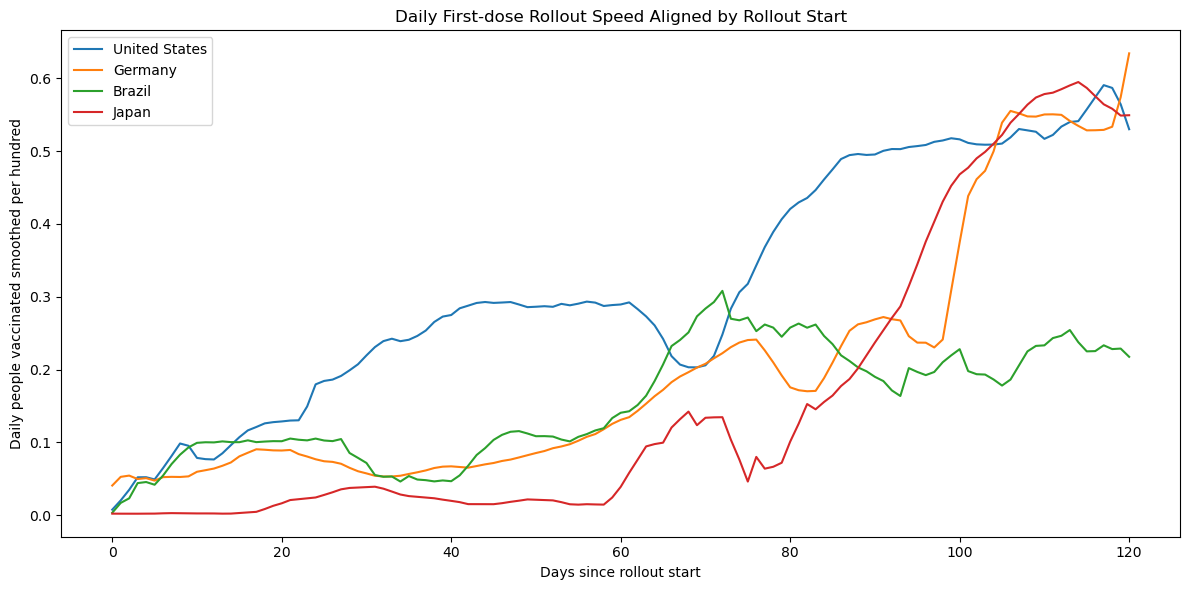

In [33]:
plt.figure(figsize=(12, 6))

for country in selected_countries_main:
    temp = aligned_df[aligned_df["country"] == country].copy()
    temp = temp[temp["rollout_day"] <= 120]
    plt.plot(temp["rollout_day"], temp["daily_people_vaccinated_smoothed_per_hundred"], label=country)

plt.title("Daily First-dose Rollout Speed Aligned by Rollout Start")
plt.xlabel("Days since rollout start")
plt.ylabel("Daily people vaccinated smoothed per hundred")
plt.legend()
plt.tight_layout()
plt.show()

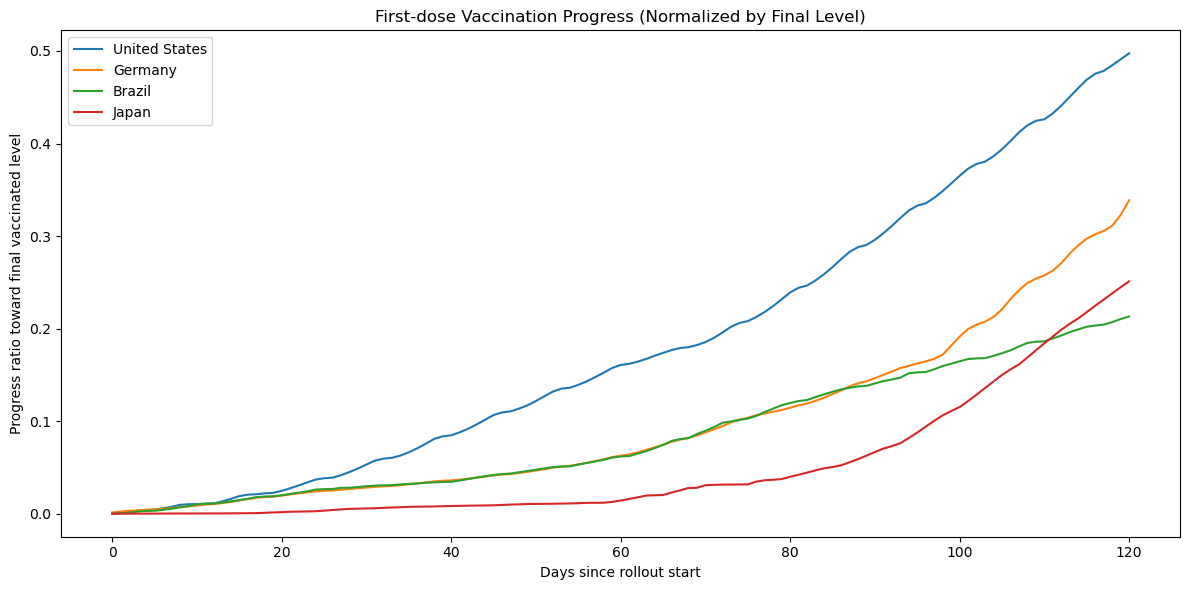

In [34]:
plt.figure(figsize=(12, 6))

for country in selected_countries_main:
    temp = aligned_df[aligned_df["country"] == country].copy()
    temp = temp[temp["rollout_day"] <= 120]
    plt.plot(temp["rollout_day"], temp["vaccinated_progress_ratio"], label=country)

plt.title("First-dose Vaccination Progress (Normalized by Final Level)")
plt.xlabel("Days since rollout start")
plt.ylabel("Progress ratio toward final vaccinated level")
plt.legend()
plt.tight_layout()
plt.show()

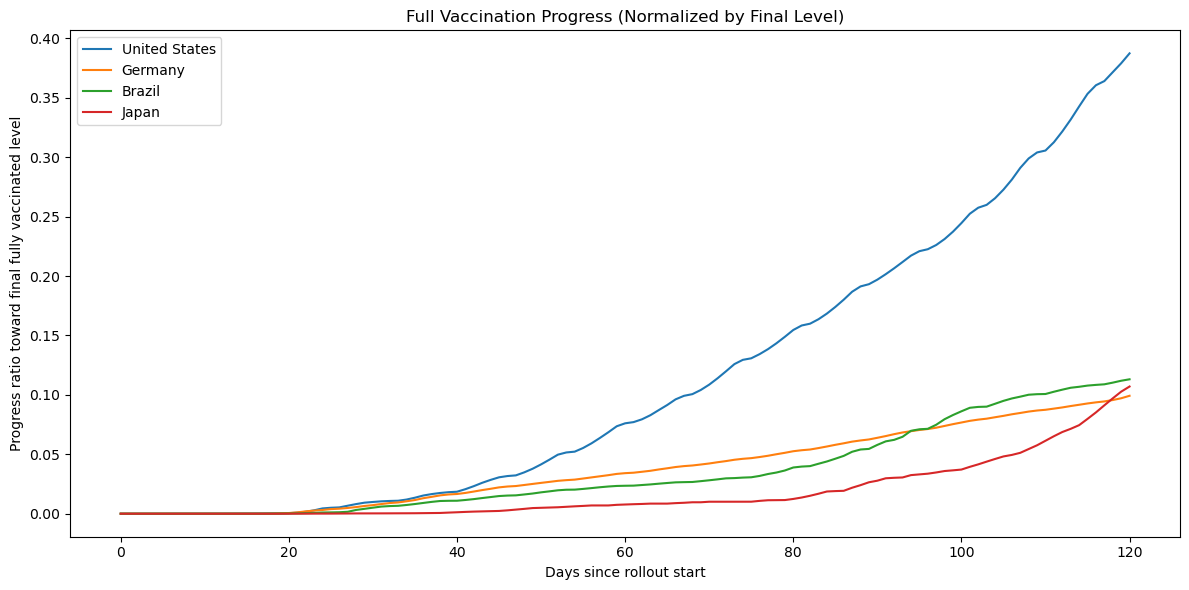

In [35]:
plt.figure(figsize=(12, 6))

for country in selected_countries_main:
    temp = aligned_df[aligned_df["country"] == country].copy()
    temp = temp[temp["rollout_day"] <= 120]
    plt.plot(temp["rollout_day"], temp["fully_vaccinated_progress_ratio"], label=country)

plt.title("Full Vaccination Progress (Normalized by Final Level)")
plt.xlabel("Days since rollout start")
plt.ylabel("Progress ratio toward final fully vaccinated level")
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
feature_rows = []

for country in selected_countries_main:
    temp = aligned_df[aligned_df["country"] == country].sort_values("rollout_day").copy()

    def get_value_on_day(df_, day, col):
        candidates = df_[df_["rollout_day"] <= day]
        if candidates.empty:
            return np.nan
        return candidates.iloc[-1][col]

    feature_rows.append({
        "country": country,
        "vaccinated_day_30_ratio": get_value_on_day(temp, 30, "vaccinated_progress_ratio"),
        "vaccinated_day_60_ratio": get_value_on_day(temp, 60, "vaccinated_progress_ratio"),
        "vaccinated_day_80_ratio": get_value_on_day(temp, 80, "vaccinated_progress_ratio"),
        "fully_vaccinated_day_30_ratio": get_value_on_day(temp, 30, "fully_vaccinated_progress_ratio"),
        "fully_vaccinated_day_60_ratio": get_value_on_day(temp, 60, "fully_vaccinated_progress_ratio"),
        "fully_vaccinated_day_80_ratio": get_value_on_day(temp, 80, "fully_vaccinated_progress_ratio"),
        "avg_daily_vaccinations_first_30_days": temp[temp["rollout_day"] <= 30]["daily_vaccinations_smoothed"].mean(),
        "avg_daily_vaccinations_first_60_days": temp[temp["rollout_day"] <= 60]["daily_vaccinations_smoothed"].mean(),
        "avg_daily_vaccinations_first_80_days": temp[temp["rollout_day"] <= 80]["daily_vaccinations_smoothed"].mean()
    })

feature_df = pd.DataFrame(feature_rows)
feature_df

,country,vaccinated_day_30_ratio,vaccinated_day_60_ratio,vaccinated_day_80_ratio,fully_vaccinated_day_30_ratio,fully_vaccinated_day_60_ratio,fully_vaccinated_day_80_ratio,avg_daily_vaccinations_first_30_days,avg_daily_vaccinations_first_60_days,avg_daily_vaccinations_first_80_days
0,United States,0.053233,0.160754,0.239155,0.009882,0.076076,0.154611,442502.155914,919094.025371,1.157981e+06
1,Germany,0.028283,0.062800,0.114560,0.007221,0.034121,0.052580,66921.839631,94540.325995,1.258519e+05
2,Brazil,0.029743,0.061905,0.119663,0.005079,0.023523,0.038891,186588.593932,241430.084036,3.321366e+05
3,Japan,0.005730,0.014235,0.039972,0.000269,0.007738,0.012424,15856.600819,32784.148426,6.012231e+04


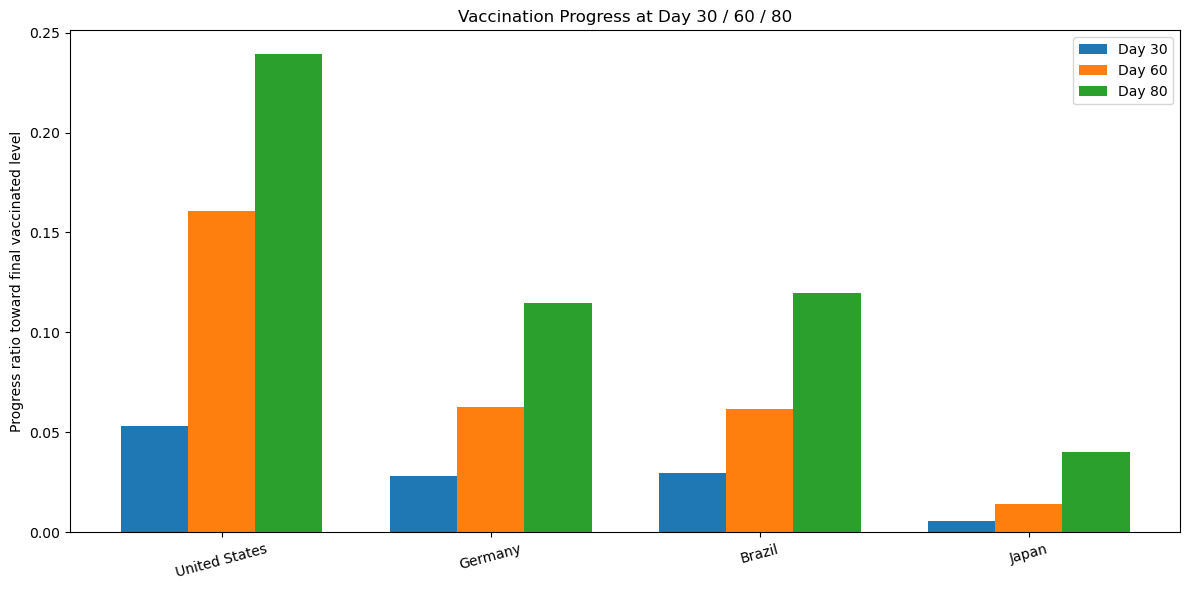

In [37]:
bar_df = feature_df[[
    "country",
    "vaccinated_day_30_ratio",
    "vaccinated_day_60_ratio",
    "vaccinated_day_80_ratio"
]].copy()

bar_df = bar_df.set_index("country")

x = np.arange(len(bar_df.index))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, bar_df["vaccinated_day_30_ratio"], width, label="Day 30")
plt.bar(x,         bar_df["vaccinated_day_60_ratio"], width, label="Day 60")
plt.bar(x + width, bar_df["vaccinated_day_80_ratio"], width, label="Day 80")

plt.xticks(x, bar_df.index, rotation=15)
plt.ylabel("Progress ratio toward final vaccinated level")
plt.title("Vaccination Progress at Day 30 / 60 / 80")
plt.legend()
plt.tight_layout()
plt.show()

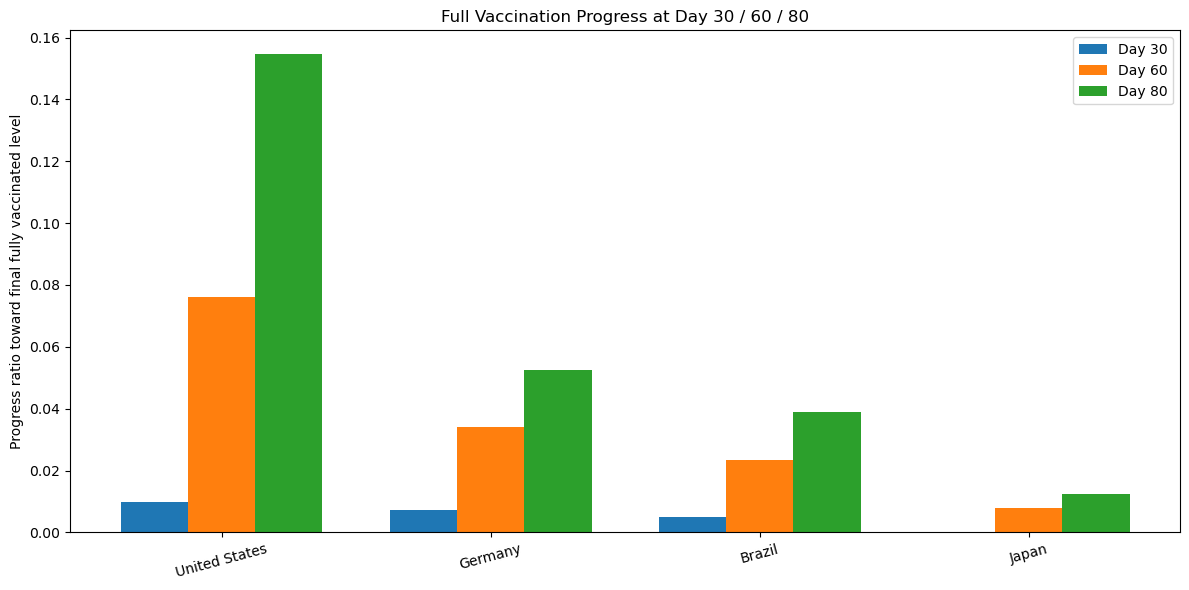

In [38]:
bar_full_df = feature_df[[
    "country",
    "fully_vaccinated_day_30_ratio",
    "fully_vaccinated_day_60_ratio",
    "fully_vaccinated_day_80_ratio"
]].copy()

bar_full_df = bar_full_df.set_index("country")

x = np.arange(len(bar_full_df.index))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, bar_full_df["fully_vaccinated_day_30_ratio"], width, label="Day 30")
plt.bar(x,         bar_full_df["fully_vaccinated_day_60_ratio"], width, label="Day 60")
plt.bar(x + width, bar_full_df["fully_vaccinated_day_80_ratio"], width, label="Day 80")

plt.xticks(x, bar_full_df.index, rotation=15)
plt.ylabel("Progress ratio toward final fully vaccinated level")
plt.title("Full Vaccination Progress at Day 30 / 60 / 80")
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
result_table = feature_df.copy()

for col in result_table.columns:
    if col != "country":
        result_table[col] = result_table[col].round(4)

result_table

,country,vaccinated_day_30_ratio,vaccinated_day_60_ratio,vaccinated_day_80_ratio,fully_vaccinated_day_30_ratio,fully_vaccinated_day_60_ratio,fully_vaccinated_day_80_ratio,avg_daily_vaccinations_first_30_days,avg_daily_vaccinations_first_60_days,avg_daily_vaccinations_first_80_days
0,United States,0.0532,0.1608,0.2392,0.0099,0.0761,0.1546,442502.1559,919094.0254,1.157981e+06
1,Germany,0.0283,0.0628,0.1146,0.0072,0.0341,0.0526,66921.8396,94540.3260,1.258519e+05
2,Brazil,0.0297,0.0619,0.1197,0.0051,0.0235,0.0389,186588.5939,241430.0840,3.321366e+05
3,Japan,0.0057,0.0142,0.0400,0.0003,0.0077,0.0124,15856.6008,32784.1484,6.012231e+04


In [40]:
plt.savefig("figure1_daily_rollout_speed.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [41]:
result_table.to_csv("vaccination_trend_result_table.csv", index=False)
start_dates_df.to_csv("vaccination_rollout_start_dates.csv", index=False)

In [42]:
candidate_countries = ["India", "Mexico", "Turkey"]

check_rows = []

for country in candidate_countries:
    temp = main_df[main_df["country"] == country].sort_values("date").copy()
    temp["vaccinated_diff"] = temp["people_vaccinated_interpolated"].diff()

    first_change_date = temp[temp["vaccinated_diff"] > 0]["date"].min()
    first_nonzero_daily = temp[temp["daily_people_vaccinated_smoothed"] > 0]["date"].min()

    check_rows.append({
        "country": country,
        "first_change_date": first_change_date,
        "first_nonzero_daily_date": first_nonzero_daily
    })

candidate_check_df = pd.DataFrame(check_rows)
candidate_check_df

,country,first_change_date,first_nonzero_daily_date
0,India,2021-01-17,2021-01-16
1,Mexico,2020-12-26,2020-12-25
2,Turkey,2021-02-13,2021-02-13


In [43]:
selected_countries_main = [
    "United States",
    "Germany",
    "Brazil",
    "Japan",
    "India",
    "Mexico",
    "Turkey"
]

In [44]:
subset = main_df[main_df["country"].isin(selected_countries_main)].copy()
print(subset["country"].unique())

['Brazil' 'Germany' 'India' 'Japan' 'Mexico' 'Turkey' 'United States']


In [45]:
aligned_rows = []

for country in selected_countries_main:
    temp = subset[subset["country"] == country].sort_values("date").copy()
    temp["vaccinated_diff"] = temp["people_vaccinated_interpolated"].diff()

    first_change_date = temp[temp["vaccinated_diff"] > 0]["date"].min()

    temp = temp[temp["date"] >= first_change_date].copy()
    temp["rollout_day"] = (temp["date"] - first_change_date).dt.days

    aligned_rows.append(temp)

aligned_df = pd.concat(aligned_rows, ignore_index=True)
aligned_df.head()

,country,date,daily_vaccinations_smoothed,daily_people_vaccinated_smoothed,daily_people_vaccinated_smoothed_per_hundred,people_vaccinated_interpolated,people_fully_vaccinated_interpolated,total_boosters_interpolated,vaccinated_diff,rollout_day
0,United States,2020-12-15,26366.500000,25533.000000,0.007476,87883.0,10161.0,0.0,46418.0,0
1,United States,2020-12-16,70961.333333,68860.333333,0.020162,243398.0,10679.0,0.0,155515.0,1
2,United States,2020-12-17,122030.500000,118706.750000,0.034757,511644.0,11505.0,0.0,268246.0,2
3,United States,2020-12-18,181834.000000,177281.000000,0.051907,923222.0,12831.0,0.0,411578.0,3
4,United States,2020-12-19,182230.500000,177700.500000,0.052030,1103020.0,13990.0,0.0,179798.0,4


In [46]:
start_dates = []

for country in selected_countries_main:
    temp = aligned_df[aligned_df["country"] == country].sort_values("rollout_day")
    first_date = temp["date"].min()

    start_dates.append({
        "country": country,
        "rollout_start_date": first_date
    })

start_dates_df = pd.DataFrame(start_dates)
start_dates_df

,country,rollout_start_date
0,United States,2020-12-15
1,Germany,2020-12-29
2,Brazil,2021-01-19
3,Japan,2021-02-19
4,India,2021-01-17
5,Mexico,2020-12-26
6,Turkey,2021-02-13


In [47]:
final_values = aligned_df.groupby("country").agg({
    "people_vaccinated_interpolated": "max",
    "people_fully_vaccinated_interpolated": "max",
    "total_boosters_interpolated": "max"
}).rename(columns={
    "people_vaccinated_interpolated": "final_people_vaccinated",
    "people_fully_vaccinated_interpolated": "final_people_fully_vaccinated",
    "total_boosters_interpolated": "final_total_boosters"
}).reset_index()

aligned_df = aligned_df.merge(final_values, on="country", how="left")

aligned_df["vaccinated_progress_ratio"] = (
    aligned_df["people_vaccinated_interpolated"] / aligned_df["final_people_vaccinated"]
)

aligned_df["fully_vaccinated_progress_ratio"] = (
    aligned_df["people_fully_vaccinated_interpolated"] / aligned_df["final_people_fully_vaccinated"]
)

aligned_df["booster_progress_ratio"] = (
    aligned_df["total_boosters_interpolated"] / aligned_df["final_total_boosters"]
)

aligned_df.head()

,country,date,daily_vaccinations_smoothed,daily_people_vaccinated_smoothed,daily_people_vaccinated_smoothed_per_hundred,people_vaccinated_interpolated,people_fully_vaccinated_interpolated,total_boosters_interpolated,vaccinated_diff,rollout_day,final_people_vaccinated,final_people_fully_vaccinated,final_total_boosters,vaccinated_progress_ratio,fully_vaccinated_progress_ratio,booster_progress_ratio
0,United States,2020-12-15,26366.500000,25533.000000,0.007476,87883.0,10161.0,0.0,46418.0,0,270227181.0,230637348.0,133062763.0,0.000325,0.000044,0.0
1,United States,2020-12-16,70961.333333,68860.333333,0.020162,243398.0,10679.0,0.0,155515.0,1,270227181.0,230637348.0,133062763.0,0.000901,0.000046,0.0
2,United States,2020-12-17,122030.500000,118706.750000,0.034757,511644.0,11505.0,0.0,268246.0,2,270227181.0,230637348.0,133062763.0,0.001893,0.000050,0.0
3,United States,2020-12-18,181834.000000,177281.000000,0.051907,923222.0,12831.0,0.0,411578.0,3,270227181.0,230637348.0,133062763.0,0.003416,0.000056,0.0
4,United States,2020-12-19,182230.500000,177700.500000,0.052030,1103020.0,13990.0,0.0,179798.0,4,270227181.0,230637348.0,133062763.0,0.004082,0.000061,0.0


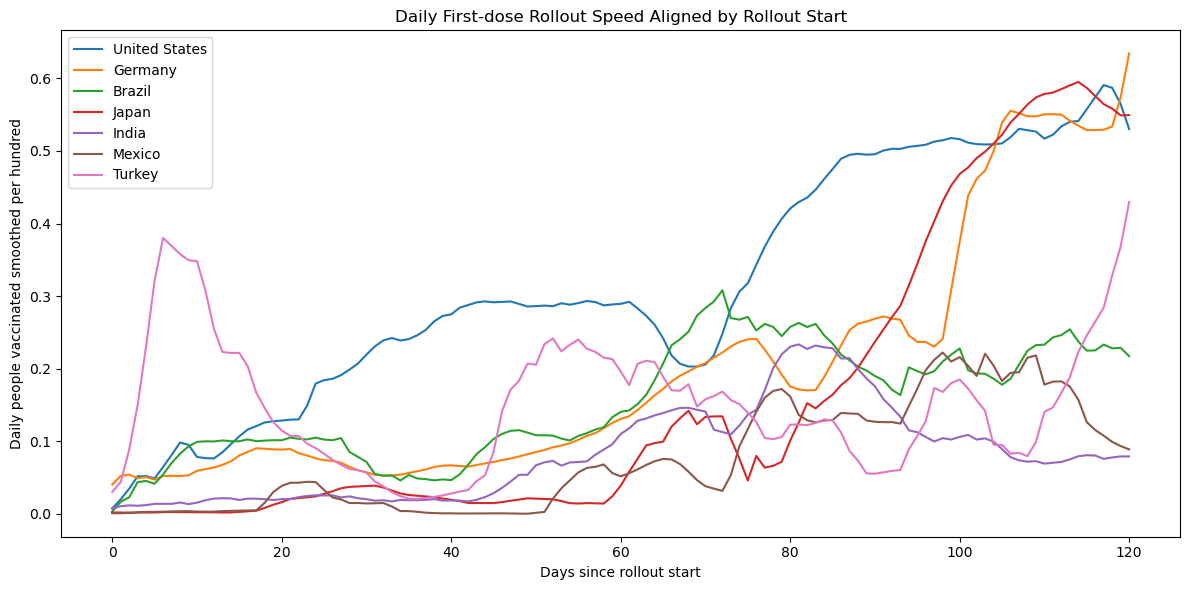

In [48]:
plt.figure(figsize=(12, 6))

for country in selected_countries_main:
    temp = aligned_df[aligned_df["country"] == country].copy()
    temp = temp[temp["rollout_day"] <= 120]
    plt.plot(temp["rollout_day"], temp["daily_people_vaccinated_smoothed_per_hundred"], label=country)

plt.title("Daily First-dose Rollout Speed Aligned by Rollout Start")
plt.xlabel("Days since rollout start")
plt.ylabel("Daily people vaccinated smoothed per hundred")
plt.legend()
plt.tight_layout()
plt.show()

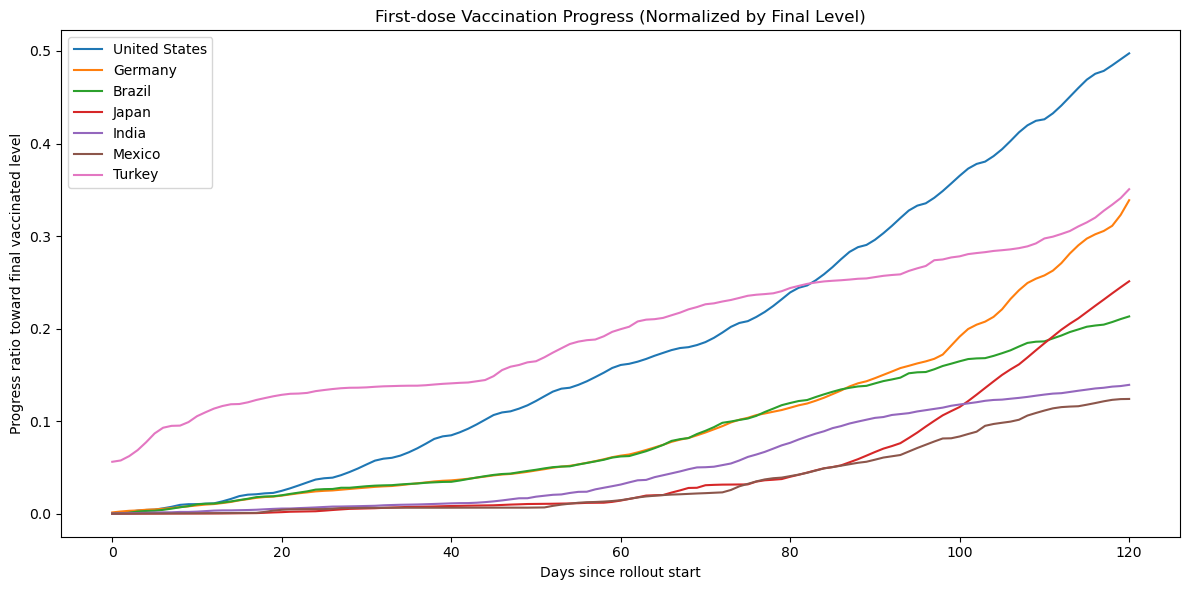

In [49]:
plt.figure(figsize=(12, 6))

for country in selected_countries_main:
    temp = aligned_df[aligned_df["country"] == country].copy()
    temp = temp[temp["rollout_day"] <= 120]
    plt.plot(temp["rollout_day"], temp["vaccinated_progress_ratio"], label=country)

plt.title("First-dose Vaccination Progress (Normalized by Final Level)")
plt.xlabel("Days since rollout start")
plt.ylabel("Progress ratio toward final vaccinated level")
plt.legend()
plt.tight_layout()
plt.show()

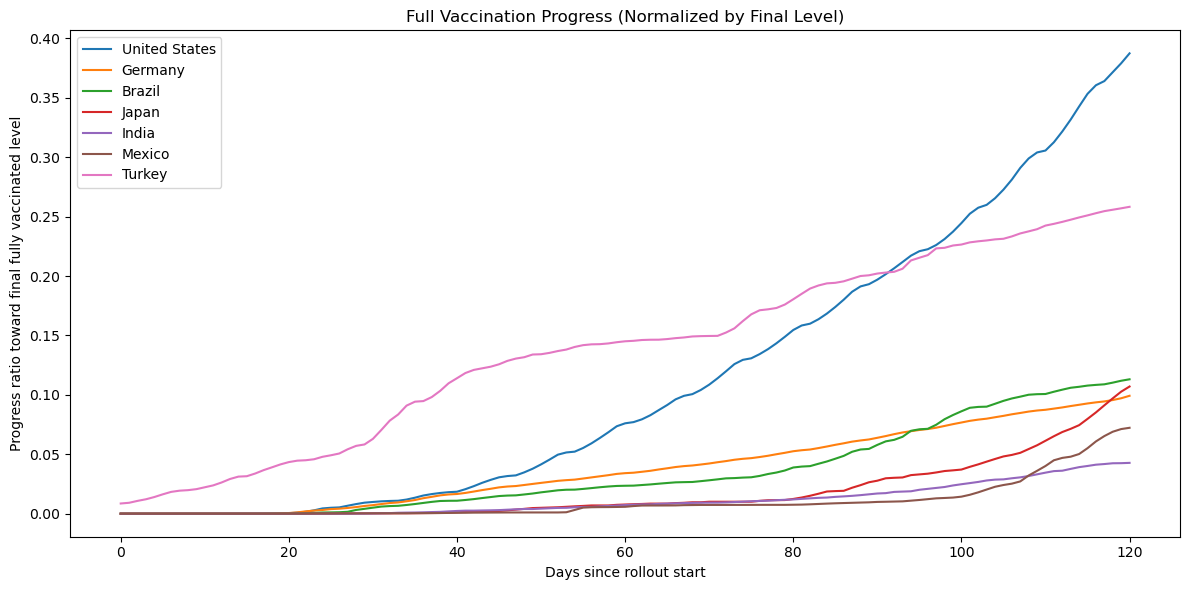

In [50]:
plt.figure(figsize=(12, 6))

for country in selected_countries_main:
    temp = aligned_df[aligned_df["country"] == country].copy()
    temp = temp[temp["rollout_day"] <= 120]
    plt.plot(temp["rollout_day"], temp["fully_vaccinated_progress_ratio"], label=country)

plt.title("Full Vaccination Progress (Normalized by Final Level)")
plt.xlabel("Days since rollout start")
plt.ylabel("Progress ratio toward final fully vaccinated level")
plt.legend()
plt.tight_layout()
plt.show()

In [51]:
feature_rows = []

for country in selected_countries_main:
    temp = aligned_df[aligned_df["country"] == country].sort_values("rollout_day").copy()

    def get_value_on_day(df_, day, col):
        candidates = df_[df_["rollout_day"] <= day]
        if candidates.empty:
            return np.nan
        return candidates.iloc[-1][col]

    feature_rows.append({
        "country": country,
        "vaccinated_day_30_ratio": get_value_on_day(temp, 30, "vaccinated_progress_ratio"),
        "vaccinated_day_60_ratio": get_value_on_day(temp, 60, "vaccinated_progress_ratio"),
        "vaccinated_day_80_ratio": get_value_on_day(temp, 80, "vaccinated_progress_ratio"),
        "fully_vaccinated_day_30_ratio": get_value_on_day(temp, 30, "fully_vaccinated_progress_ratio"),
        "fully_vaccinated_day_60_ratio": get_value_on_day(temp, 60, "fully_vaccinated_progress_ratio"),
        "fully_vaccinated_day_80_ratio": get_value_on_day(temp, 80, "fully_vaccinated_progress_ratio"),
        "avg_daily_vaccinations_first_30_days": temp[temp["rollout_day"] <= 30]["daily_vaccinations_smoothed"].mean(),
        "avg_daily_vaccinations_first_60_days": temp[temp["rollout_day"] <= 60]["daily_vaccinations_smoothed"].mean(),
        "avg_daily_vaccinations_first_80_days": temp[temp["rollout_day"] <= 80]["daily_vaccinations_smoothed"].mean()
    })

feature_df = pd.DataFrame(feature_rows)
feature_df

,country,vaccinated_day_30_ratio,vaccinated_day_60_ratio,vaccinated_day_80_ratio,fully_vaccinated_day_30_ratio,fully_vaccinated_day_60_ratio,fully_vaccinated_day_80_ratio,avg_daily_vaccinations_first_30_days,avg_daily_vaccinations_first_60_days,avg_daily_vaccinations_first_80_days
0,United States,0.053233,0.160754,0.239155,0.009882,0.076076,0.154611,442502.155914,919094.025371,1.157981e+06
1,Germany,0.028283,0.062800,0.114560,0.007221,0.034121,0.052580,66921.839631,94540.325995,1.258519e+05
2,Brazil,0.029743,0.061905,0.119663,0.005079,0.023523,0.038891,186588.593932,241430.084036,3.321366e+05
3,Japan,0.005730,0.014235,0.039972,0.000269,0.007738,0.012424,15856.600819,32784.148426,6.012231e+04
4,India,0.008410,0.031560,0.076660,0.000227,0.007262,0.012012,268103.971659,548799.897775,9.864073e+05
5,Mexico,0.006343,0.014668,0.040675,0.000351,0.005808,0.007555,18731.051843,27348.625878,5.077176e+04
6,Turkey,0.136552,0.199449,0.243906,0.062991,0.145108,0.180472,255070.594470,259391.119438,2.483113e+05


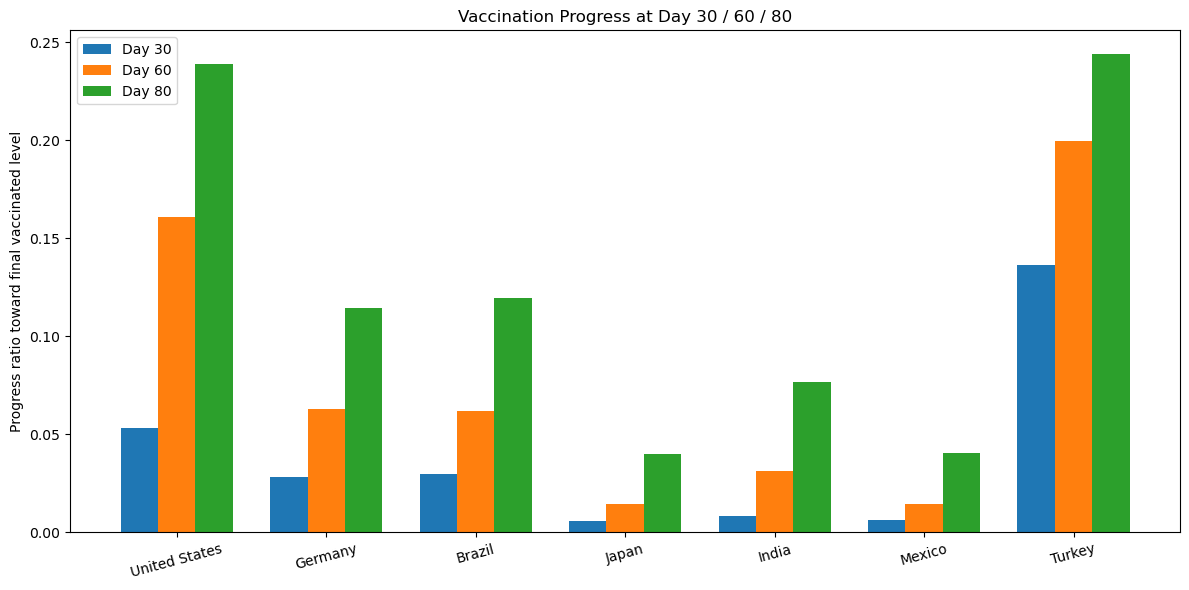

In [52]:
bar_df = feature_df[[
    "country",
    "vaccinated_day_30_ratio",
    "vaccinated_day_60_ratio",
    "vaccinated_day_80_ratio"
]].copy()

bar_df = bar_df.set_index("country")

x = np.arange(len(bar_df.index))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, bar_df["vaccinated_day_30_ratio"], width, label="Day 30")
plt.bar(x,         bar_df["vaccinated_day_60_ratio"], width, label="Day 60")
plt.bar(x + width, bar_df["vaccinated_day_80_ratio"], width, label="Day 80")

plt.xticks(x, bar_df.index, rotation=15)
plt.ylabel("Progress ratio toward final vaccinated level")
plt.title("Vaccination Progress at Day 30 / 60 / 80")
plt.legend()
plt.tight_layout()
plt.show()

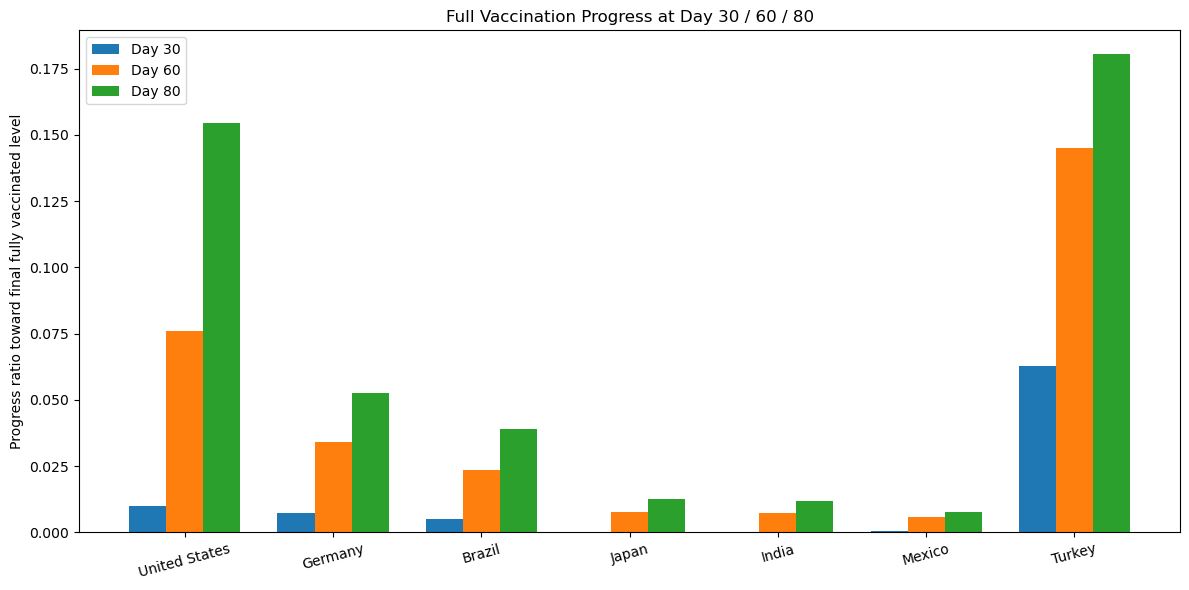

In [53]:
bar_full_df = feature_df[[
    "country",
    "fully_vaccinated_day_30_ratio",
    "fully_vaccinated_day_60_ratio",
    "fully_vaccinated_day_80_ratio"
]].copy()

bar_full_df = bar_full_df.set_index("country")

x = np.arange(len(bar_full_df.index))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, bar_full_df["fully_vaccinated_day_30_ratio"], width, label="Day 30")
plt.bar(x,         bar_full_df["fully_vaccinated_day_60_ratio"], width, label="Day 60")
plt.bar(x + width, bar_full_df["fully_vaccinated_day_80_ratio"], width, label="Day 80")

plt.xticks(x, bar_full_df.index, rotation=15)
plt.ylabel("Progress ratio toward final fully vaccinated level")
plt.title("Full Vaccination Progress at Day 30 / 60 / 80")
plt.legend()
plt.tight_layout()
plt.show()

In [54]:
result_table = feature_df.copy()

for col in result_table.columns:
    if col != "country":
        result_table[col] = result_table[col].round(4)

result_table

,country,vaccinated_day_30_ratio,vaccinated_day_60_ratio,vaccinated_day_80_ratio,fully_vaccinated_day_30_ratio,fully_vaccinated_day_60_ratio,fully_vaccinated_day_80_ratio,avg_daily_vaccinations_first_30_days,avg_daily_vaccinations_first_60_days,avg_daily_vaccinations_first_80_days
0,United States,0.0532,0.1608,0.2392,0.0099,0.0761,0.1546,442502.1559,919094.0254,1.157981e+06
1,Germany,0.0283,0.0628,0.1146,0.0072,0.0341,0.0526,66921.8396,94540.3260,1.258519e+05
2,Brazil,0.0297,0.0619,0.1197,0.0051,0.0235,0.0389,186588.5939,241430.0840,3.321366e+05
3,Japan,0.0057,0.0142,0.0400,0.0003,0.0077,0.0124,15856.6008,32784.1484,6.012231e+04
4,India,0.0084,0.0316,0.0767,0.0002,0.0073,0.0120,268103.9717,548799.8978,9.864073e+05
5,Mexico,0.0063,0.0147,0.0407,0.0004,0.0058,0.0076,18731.0518,27348.6259,5.077176e+04
6,Turkey,0.1366,0.1994,0.2439,0.0630,0.1451,0.1805,255070.5945,259391.1194,2.483113e+05


In [55]:
age_df = pd.read_csv("cleaned_vaccinations_age.csv")
print(age_df.shape)
age_df.head()

(64621, 6)


,country,age_group,date,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,people_with_booster_per_hundred
0,Argentina,100+,2020-01-01,0.0,0.0,0.0
1,Argentina,100+,2020-01-02,0.0,0.0,0.0
2,Argentina,100+,2020-01-03,0.0,0.0,0.0
3,Argentina,100+,2020-01-04,0.0,0.0,0.0
4,Argentina,100+,2020-01-05,0.0,0.0,0.0


In [56]:
print(age_df.columns.tolist())

['country', 'age_group', 'date', 'people_vaccinated_per_hundred', 'people_fully_vaccinated_per_hundred', 'people_with_booster_per_hundred']


In [57]:
age_df.info()
print(age_df.isnull().sum().sort_values(ascending=False).head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64621 entries, 0 to 64620
Data columns (total 6 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   country                              64621 non-null  object 
 1   age_group                            64621 non-null  object 
 2   date                                 64621 non-null  object 
 3   people_vaccinated_per_hundred        64621 non-null  float64
 4   people_fully_vaccinated_per_hundred  64621 non-null  float64
 5   people_with_booster_per_hundred      64621 non-null  float64
dtypes: float64(3), object(3)
memory usage: 3.0+ MB
country                                0
age_group                              0
date                                   0
people_vaccinated_per_hundred          0
people_fully_vaccinated_per_hundred    0
people_with_booster_per_hundred        0
dtype: int64


In [58]:
[c for c in age_df.columns if "age" in c.lower() or "vacc" in c.lower() or "booster" in c.lower() or "date" in c.lower() or "group" in c.lower()]

['age_group',
 'date',
 'people_vaccinated_per_hundred',
 'people_fully_vaccinated_per_hundred',
 'people_with_booster_per_hundred']

In [59]:
age_df.head(20)

,country,age_group,date,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,people_with_booster_per_hundred
0,Argentina,100+,2020-01-01,0.0,0.0,0.0
1,Argentina,100+,2020-01-02,0.0,0.0,0.0
2,Argentina,100+,2020-01-03,0.0,0.0,0.0
3,Argentina,100+,2020-01-04,0.0,0.0,0.0
4,Argentina,100+,2020-01-05,0.0,0.0,0.0
5,Argentina,100+,2020-01-06,0.0,0.0,0.0
6,Argentina,100+,2020-01-07,0.0,0.0,0.0
7,Argentina,100+,2020-01-08,0.0,0.0,0.0
8,Argentina,100+,2020-01-09,0.0,0.0,0.0
9,Argentina,100+,2020-01-10,0.0,0.0,0.0


In [60]:
possible_country_cols = [c for c in age_df.columns if "country" in c.lower() or "location" in c.lower()]
possible_country_cols

['country']

In [61]:
possible_age_cols = [c for c in age_df.columns if "age" in c.lower() or "group" in c.lower()]
possible_age_cols

['age_group']

In [62]:
possible_date_cols = [c for c in age_df.columns if "date" in c.lower() or "day" in c.lower()]
possible_date_cols

['date']

In [63]:
age_col = "age_group"   # 这里改成你真实的年龄层列名
print(age_df[age_col].dropna().unique())

['100+' '12-17' '18-29' '3-11' '30-39' '40-49' '50-59' '60-69' '70-79'
 '80-89' '90-99' '0-4' '10-14' '15-17' '18-24' '25-49' '5-9' '80+' '0-17'
 '0-15' '16-69' '18-69' '5-11' '0-19' '20-29' '12-15' '16-19' '90+' '0-5'
 '12-64' '65+' '16-17' '50-54' '55-59' '60-64' '65-69' '70-74' '75-79']


In [64]:
country_col = "country"   # 这里改成你真实的国家列名
print(age_df[country_col].dropna().nunique())
print(age_df[country_col].dropna().unique()[:30])

35
['Argentina' 'Austria' 'Belgium' 'Bulgaria' 'Canada' 'Croatia' 'Cyprus'
 'Czechia' 'Denmark' 'Estonia' 'Finland' 'France' 'Hong Kong' 'Hungary'
 'Iceland' 'Ireland' 'Israel' 'Italy' 'Japan' 'Jersey' 'Latvia'
 'Liechtenstein' 'Lithuania' 'Luxembourg' 'Malta' 'Netherlands' 'Norway'
 'Peru' 'Poland' 'Portugal']


In [65]:
target_countries = ["United States", "Germany", "Japan", "Brazil"]
for c in target_countries:
    print(c, c in set(age_df[country_col].dropna().unique()))

United States False
Germany False
Japan True
Brazil False


In [66]:
possible_metric_cols = [c for c in age_df.columns if any(k in c.lower() for k in ["vacc", "booster", "hundred", "rate", "coverage", "fully"])]
possible_metric_cols

['people_vaccinated_per_hundred',
 'people_fully_vaccinated_per_hundred',
 'people_with_booster_per_hundred']

In [67]:
age_df["date"] = pd.to_datetime(age_df["date"])

In [68]:
country_age_summary = (
    age_df.groupby("country")
    .agg(
        n_age_groups=("age_group", "nunique"),
        min_date=("date", "min"),
        max_date=("date", "max"),
        n_rows=("country", "size"),
        vacc_nonzero_ratio=("people_vaccinated_per_hundred", lambda x: (x > 0).mean()),
        full_nonzero_ratio=("people_fully_vaccinated_per_hundred", lambda x: (x > 0).mean()),
        booster_nonzero_ratio=("people_with_booster_per_hundred", lambda x: (x > 0).mean()),
    )
    .sort_values(["n_age_groups", "n_rows"], ascending=[False, False])
)

country_age_summary

,n_age_groups,min_date,max_date,n_rows,vacc_nonzero_ratio,full_nonzero_ratio,booster_nonzero_ratio
country,,,,,,,
Jersey,13,2021-09-26,2023-01-29,1087,0.997240,0.982521,0.918123
Canada,13,2020-12-19,2024-06-30,753,0.988048,0.867198,0.414343
Argentina,11,2020-01-01,2024-01-28,16379,0.731180,0.708407,0.571952
Israel,11,2021-08-05,2022-04-04,2491,1.000000,0.993577,0.916901
Poland,10,2021-01-01,2023-09-29,1432,0.899441,0.879190,0.646648
Portugal,10,2021-01-01,2023-09-29,1349,0.988881,0.939214,0.865827
Croatia,10,2021-01-01,2023-09-29,1335,0.945318,0.925094,0.626217
Lithuania,10,2021-01-01,2023-09-29,1332,0.985736,0.915916,0.635135
Austria,10,2021-01-08,2023-06-30,1299,0.973826,0.930716,0.785219


In [69]:
candidate_countries_age = country_age_summary[
    (country_age_summary["n_age_groups"] >= 6) &
    (country_age_summary["vacc_nonzero_ratio"] > 0.10) &
    (country_age_summary["full_nonzero_ratio"] > 0.10) &
    (country_age_summary["booster_nonzero_ratio"] > 0.05)
].copy()

candidate_countries_age

,n_age_groups,min_date,max_date,n_rows,vacc_nonzero_ratio,full_nonzero_ratio,booster_nonzero_ratio
country,,,,,,,
Jersey,13,2021-09-26,2023-01-29,1087,0.997240,0.982521,0.918123
Canada,13,2020-12-19,2024-06-30,753,0.988048,0.867198,0.414343
Argentina,11,2020-01-01,2024-01-28,16379,0.731180,0.708407,0.571952
Israel,11,2021-08-05,2022-04-04,2491,1.000000,0.993577,0.916901
Poland,10,2021-01-01,2023-09-29,1432,0.899441,0.879190,0.646648
Portugal,10,2021-01-01,2023-09-29,1349,0.988881,0.939214,0.865827
Croatia,10,2021-01-01,2023-09-29,1335,0.945318,0.925094,0.626217
Lithuania,10,2021-01-01,2023-09-29,1332,0.985736,0.915916,0.635135
Austria,10,2021-01-08,2023-06-30,1299,0.973826,0.930716,0.785219


In [70]:
candidate_countries_age.index.tolist()

['Jersey',
 'Canada',
 'Argentina',
 'Israel',
 'Poland',
 'Portugal',
 'Croatia',
 'Lithuania',
 'Austria',
 'Netherlands',
 'Ireland',
 'Czechia',
 'Cyprus',
 'Iceland',
 'Slovakia',
 'Latvia',
 'Denmark',
 'Spain',
 'Finland',
 'Luxembourg',
 'Liechtenstein',
 'Hong Kong',
 'Italy',
 'Estonia',
 'Sweden',
 'Hungary',
 'Malta',
 'Norway',
 'Belgium',
 'Bulgaria',
 'France',
 'Slovenia',
 'Romania',
 'Peru']

In [71]:
for c in candidate_countries_age.index.tolist():
    print("========", c, "========")
    print(sorted(age_df[age_df["country"] == c]["age_group"].dropna().unique()))
    print()

======== Jersey ========
['12-15', '16-17', '18-29', '30-39', '40-49', '5-11', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80+']

======== Canada ========
['0-15', '0-4', '12-17', '16-69', '18-29', '18-69', '30-39', '40-49', '5-11', '50-59', '60-69', '70-79', '80+']

======== Argentina ========
['100+', '12-17', '18-29', '3-11', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90-99']

======== Israel ========
['12-15', '16-19', '20-29', '30-39', '40-49', '5-11', '50-59', '60-69', '70-79', '80-89', '90+']

======== Poland ========
['0-4', '10-14', '15-17', '18-24', '25-49', '5-9', '50-59', '60-69', '70-79', '80+']

======== Portugal ========
['0-4', '10-14', '15-17', '18-24', '25-49', '5-9', '50-59', '60-69', '70-79', '80+']

======== Croatia ========
['0-4', '10-14', '15-17', '18-24', '25-49', '5-9', '50-59', '60-69', '70-79', '80+']

======== Lithuania ========
['0-4', '10-14', '15-17', '18-24', '25-49', '5-9', '50-59', '60-69', '70-79', '80+']

======== Austria ====

In [72]:
selected_age_countries = ["France", "Belgium", "Romania", "Peru"]

In [73]:
for c in selected_age_countries:
    print("========", c, "========")
    print(sorted(age_df[age_df["country"] == c]["age_group"].dropna().unique()))
    print()

======== France ========
['0-17', '18-24', '25-49', '50-59', '60-69', '70-79', '80+']

======== Belgium ========
['0-17', '18-24', '25-49', '50-59', '60-69', '70-79', '80+']

======== Romania ========
['0-17', '18-24', '25-49', '50-59', '60-69', '70-79', '80+']

======== Peru ========
['0-17', '18-24', '25-49', '50-59', '60-69', '70-79', '80+']



In [74]:
age_start_check_rows = []

for country in selected_age_countries:
    temp = age_df[age_df["country"] == country].copy()
    temp["date"] = pd.to_datetime(temp["date"])

    first_nonzero_vacc = temp[temp["people_vaccinated_per_hundred"] > 0]["date"].min()
    first_nonzero_full = temp[temp["people_fully_vaccinated_per_hundred"] > 0]["date"].min()
    first_nonzero_booster = temp[temp["people_with_booster_per_hundred"] > 0]["date"].min()

    age_start_check_rows.append({
        "country": country,
        "table_start_date": temp["date"].min(),
        "table_end_date": temp["date"].max(),
        "first_nonzero_vacc_date": first_nonzero_vacc,
        "first_nonzero_full_date": first_nonzero_full,
        "first_nonzero_booster_date": first_nonzero_booster
    })

age_start_check_df = pd.DataFrame(age_start_check_rows)
age_start_check_df

,country,table_start_date,table_end_date,first_nonzero_vacc_date,first_nonzero_full_date,first_nonzero_booster_date
0,France,2021-01-01,2023-07-07,2021-01-08,2021-01-22,2021-09-03
1,Belgium,2021-01-08,2023-09-01,2021-01-08,2021-01-22,2021-09-10
2,Romania,2021-05-28,2023-09-29,2021-05-28,2021-05-28,2021-11-05
3,Peru,2021-10-16,2023-12-09,2021-10-16,2021-10-16,2021-10-16


In [75]:
for country in selected_age_countries:
    print("========", country, "========")
    temp = age_df[age_df["country"] == country].copy()
    temp["date"] = pd.to_datetime(temp["date"])
    print(temp.sort_values("date").head(20))
    print()

======== France ========
      country age_group       date  people_vaccinated_per_hundred  \
27406  France      0-17 2021-01-01                           0.00   
27802  France     50-59 2021-01-01                           0.00   
27934  France     60-69 2021-01-01                           0.00   
27670  France     25-49 2021-01-01                           0.00   
27538  France     18-24 2021-01-01                           0.00   
28198  France       80+ 2021-01-01                           0.00   
28066  France     70-79 2021-01-01                           0.00   
27803  France     50-59 2021-01-08                           0.45   
28067  France     70-79 2021-01-08                           0.16   
27407  France      0-17 2021-01-08                           0.00   
27539  France     18-24 2021-01-08                           0.03   
27671  France     25-49 2021-01-08                           0.09   
28199  France       80+ 2021-01-08                           0.42   
27935  Fr

In [76]:
selected_age_countries = ["France", "Belgium", "Romania"]

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

age_df["date"] = pd.to_datetime(age_df["date"])

selected_age_groups = ["0-17", "18-24", "25-49", "50-59", "60-69", "70-79", "80+"]

age_main_df = age_df[
    (age_df["country"].isin(selected_age_countries)) &
    (age_df["age_group"].isin(selected_age_groups))
].copy()

age_main_df = age_main_df.sort_values(["country", "age_group", "date"]).reset_index(drop=True)

print(age_main_df["country"].unique())
print(sorted(age_main_df["age_group"].unique()))
age_main_df.head()

['Belgium' 'France' 'Romania']
['0-17', '18-24', '25-49', '50-59', '60-69', '70-79', '80+']


,country,age_group,date,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,people_with_booster_per_hundred
0,Belgium,0-17,2021-01-08,0.0,0.0,0.0
1,Belgium,0-17,2021-01-15,0.0,0.0,0.0
2,Belgium,0-17,2021-01-22,0.0,0.0,0.0
3,Belgium,0-17,2021-01-29,0.0,0.0,0.0
4,Belgium,0-17,2021-02-05,0.0,0.0,0.0


In [78]:
age_main_df.groupby(["country", "age_group"])["date"].agg(["min", "max", "count"])

min        max  count
country age_group                             
Belgium 0-17      2021-01-08 2023-09-01    139
        18-24     2021-01-08 2023-09-01    139
        25-49     2021-01-08 2023-09-01    139
        50-59     2021-01-08 2023-09-01    139
        60-69     2021-01-08 2023-09-01    139
        70-79     2021-01-08 2023-09-01    139
        80+       2021-01-08 2023-09-01    139
France  0-17      2021-01-01 2023-07-07    132
        18-24     2021-01-01 2023-07-07    132
        25-49     2021-01-01 2023-07-07    132
        50-59     2021-01-01 2023-07-07    132
        60-69     2021-01-01 2023-07-07    132
        70-79     2021-01-01 2023-07-07    132
        80+       2021-01-01 2023-07-07    132
Romania 0-17      2021-05-28 2023-09-29    122
        18-24     2021-05-28 2023-09-29    122
        25-49     2021-05-28 2023-09-29    122
        50-59     2021-05-28 2023-09-29    122
        60-69     2021-05-28 2023-09-29    122
        70-79     2021-05-28 2023-09-29    122
        80+       2021-05-28 2023-09-29    122

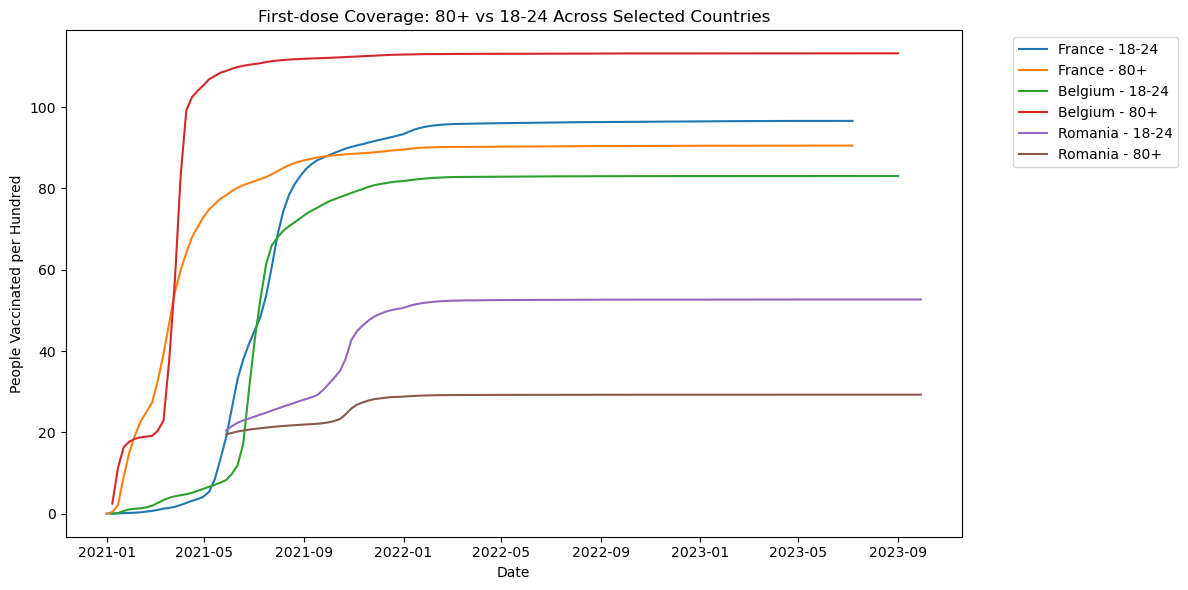

In [79]:
plt.figure(figsize=(12, 6))

focus_groups = ["18-24", "80+"]

for country in selected_age_countries:
    for age_group in focus_groups:
        temp = age_main_df[
            (age_main_df["country"] == country) &
            (age_main_df["age_group"] == age_group)
        ].sort_values("date")

        plt.plot(
            temp["date"],
            temp["people_vaccinated_per_hundred"],
            label=f"{country} - {age_group}"
        )

plt.title("First-dose Coverage: 80+ vs 18-24 Across Selected Countries")
plt.xlabel("Date")
plt.ylabel("People Vaccinated per Hundred")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [80]:
snapshot_date = pd.Timestamp("2022-01-01")

snapshot_df = age_main_df[age_main_df["date"] == snapshot_date].copy()
snapshot_df

,country,age_group,date,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,people_with_booster_per_hundred


In [81]:
snapshot_date = pd.Timestamp("2022-01-08")

In [82]:
snapshot_date = pd.Timestamp("2022-02-01")

共同日期数量: 110
前几个共同日期: [Timestamp('2021-05-28 00:00:00'), Timestamp('2021-06-04 00:00:00'), Timestamp('2021-06-11 00:00:00'), Timestamp('2021-06-18 00:00:00'), Timestamp('2021-06-25 00:00:00'), Timestamp('2021-07-02 00:00:00'), Timestamp('2021-07-09 00:00:00'), Timestamp('2021-07-16 00:00:00'), Timestamp('2021-07-23 00:00:00'), Timestamp('2021-07-30 00:00:00')]
后几个共同日期: [Timestamp('2023-05-05 00:00:00'), Timestamp('2023-05-12 00:00:00'), Timestamp('2023-05-19 00:00:00'), Timestamp('2023-05-26 00:00:00'), Timestamp('2023-06-02 00:00:00'), Timestamp('2023-06-09 00:00:00'), Timestamp('2023-06-16 00:00:00'), Timestamp('2023-06-23 00:00:00'), Timestamp('2023-06-30 00:00:00'), Timestamp('2023-07-07 00:00:00')]
选中的 snapshot_date: 2022-06-17 00:00:00
(21, 6)
当日年龄组: ['0-17', '18-24', '25-49', '50-59', '60-69', '70-79', '80+']


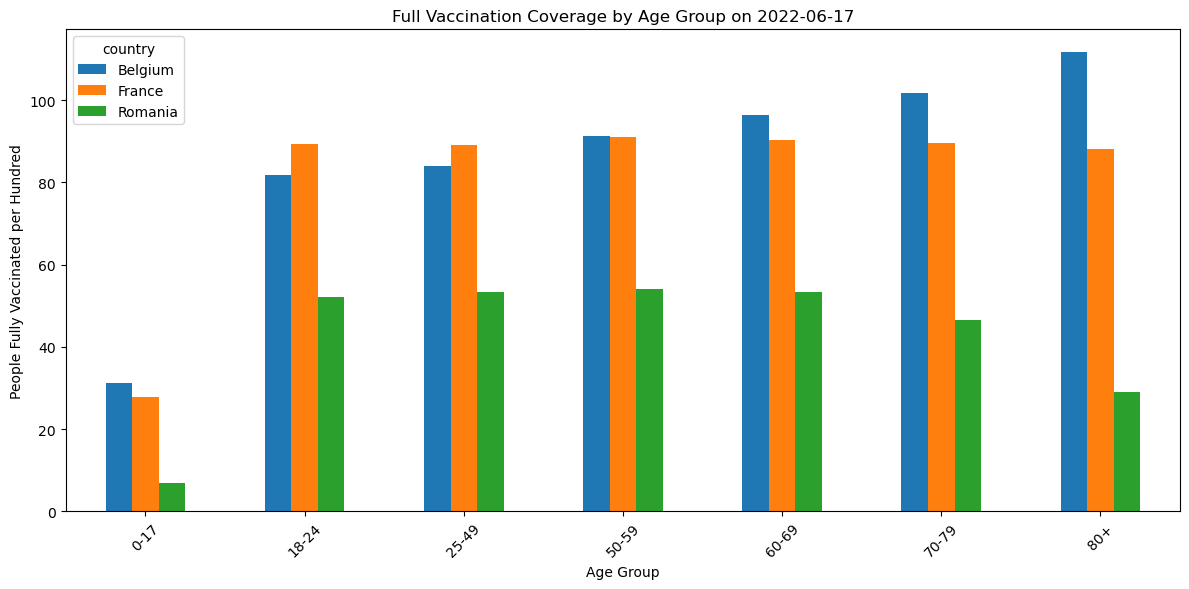

In [85]:
common_dates = set(age_main_df[age_main_df["country"] == "France"]["date"]) \
    & set(age_main_df[age_main_df["country"] == "Belgium"]["date"]) \
    & set(age_main_df[age_main_df["country"] == "Romania"]["date"])

common_dates = sorted(common_dates)
print("共同日期数量:", len(common_dates))
print("前几个共同日期:", common_dates[:10])
print("后几个共同日期:", common_dates[-10:])

snapshot_date = common_dates[len(common_dates)//2]
print("选中的 snapshot_date:", snapshot_date)

snapshot_df = age_main_df[age_main_df["date"] == snapshot_date].copy()
print(snapshot_df.shape)
print("当日年龄组:", sorted(snapshot_df["age_group"].unique()))

pivot_full = snapshot_df.pivot(
    index="age_group",
    columns="country",
    values="people_fully_vaccinated_per_hundred"
)

pivot_full = pivot_full.reindex(selected_age_groups)

pivot_full.plot(kind="bar", figsize=(12, 6))
plt.title(f"Full Vaccination Coverage by Age Group on {snapshot_date.date()}")
plt.xlabel("Age Group")
plt.ylabel("People Fully Vaccinated per Hundred")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [86]:
gap_rows = []

for country in selected_age_countries:
    temp = age_main_df[age_main_df["country"] == country].copy()

    old_df = temp[temp["age_group"] == "80+"][["date", "people_vaccinated_per_hundred"]].rename(
        columns={"people_vaccinated_per_hundred": "old_80_plus"}
    )
    young_df = temp[temp["age_group"] == "18-24"][["date", "people_vaccinated_per_hundred"]].rename(
        columns={"people_vaccinated_per_hundred": "young_18_24"}
    )

    merged = pd.merge(old_df, young_df, on="date", how="inner")
    merged["age_priority_gap"] = merged["old_80_plus"] - merged["young_18_24"]
    merged["country"] = country

    gap_rows.append(merged)

gap_df = pd.concat(gap_rows, ignore_index=True)
gap_df.head()

,date,old_80_plus,young_18_24,age_priority_gap,country
0,2021-01-01,0.00,0.00,0.00,France
1,2021-01-08,0.42,0.03,0.39,France
2,2021-01-15,2.13,0.08,2.05,France
3,2021-01-22,9.10,0.15,8.95,France
4,2021-01-29,15.13,0.20,14.93,France


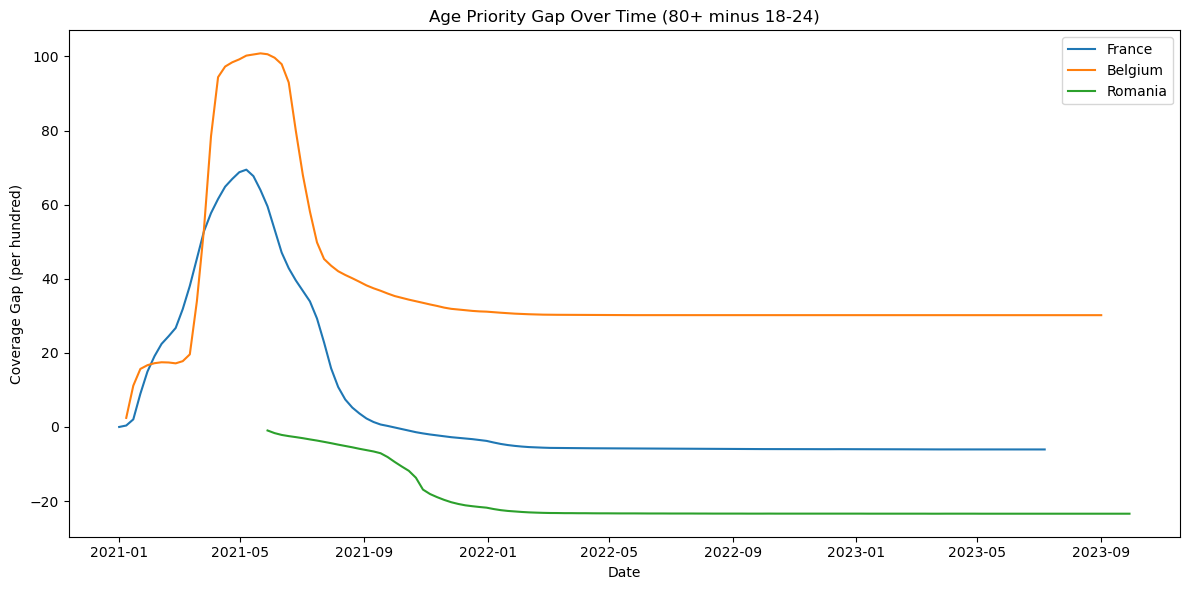

In [87]:
plt.figure(figsize=(12, 6))

for country in selected_age_countries:
    temp = gap_df[gap_df["country"] == country].sort_values("date")
    plt.plot(temp["date"], temp["age_priority_gap"], label=country)

plt.title("Age Priority Gap Over Time (80+ minus 18-24)")
plt.xlabel("Date")
plt.ylabel("Coverage Gap (per hundred)")
plt.legend()
plt.tight_layout()
plt.show()

In [88]:
gap_snapshot_rows = []

for country in selected_age_countries:
    temp = age_main_df[
        (age_main_df["country"] == country) &
        (age_main_df["date"] == snapshot_date)
    ].copy()

    old_val = temp[temp["age_group"] == "80+"]["people_vaccinated_per_hundred"]
    young_val = temp[temp["age_group"] == "18-24"]["people_vaccinated_per_hundred"]

    gap_snapshot_rows.append({
        "country": country,
        "vacc_80_plus": old_val.iloc[0] if len(old_val) > 0 else np.nan,
        "vacc_18_24": young_val.iloc[0] if len(young_val) > 0 else np.nan,
        "priority_gap_80_vs_18_24": (
            old_val.iloc[0] - young_val.iloc[0]
            if len(old_val) > 0 and len(young_val) > 0 else np.nan
        )
    })

gap_snapshot_df = pd.DataFrame(gap_snapshot_rows)
gap_snapshot_df

,country,vacc_80_plus,vacc_18_24,priority_gap_80_vs_18_24
0,France,90.31,96.16,-5.85
1,Belgium,113.12,82.94,30.18
2,Romania,29.23,52.58,-23.35


In [89]:
plt.savefig("age_fig1_80plus_vs_18to24_firstdose.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

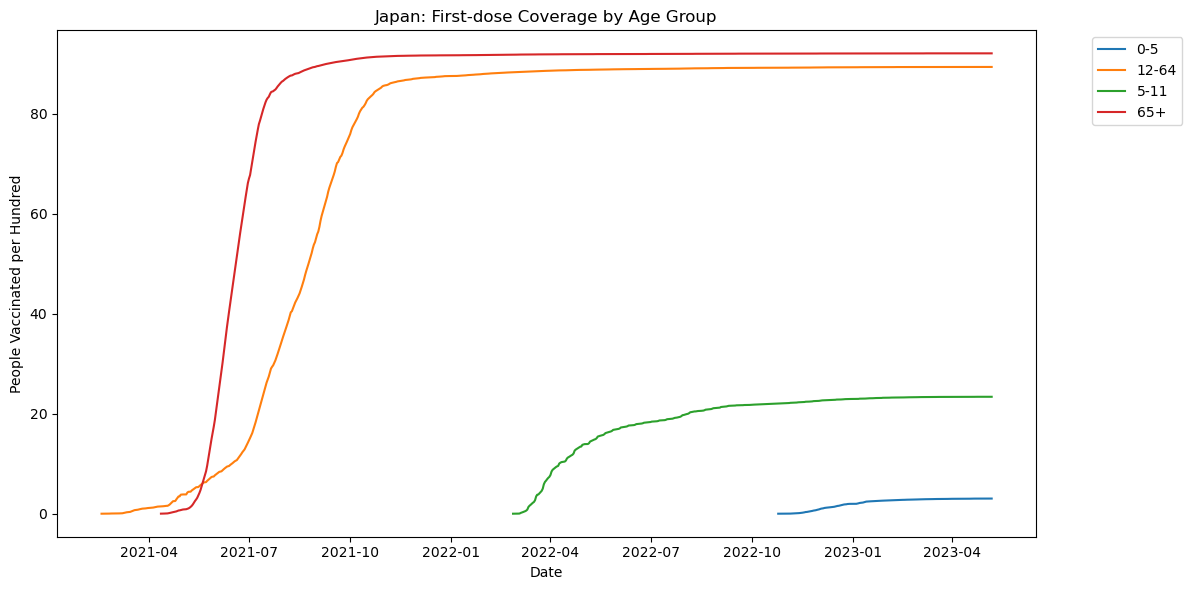

In [90]:
japan_age_df = age_df[age_df["country"] == "Japan"].copy()
japan_age_df["date"] = pd.to_datetime(japan_age_df["date"])

plt.figure(figsize=(12, 6))

for age_group in sorted(japan_age_df["age_group"].dropna().unique()):
    temp = japan_age_df[japan_age_df["age_group"] == age_group].sort_values("date")
    plt.plot(temp["date"], temp["people_vaccinated_per_hundred"], label=age_group)

plt.title("Japan: First-dose Coverage by Age Group")
plt.xlabel("Date")
plt.ylabel("People Vaccinated per Hundred")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [92]:
result_table.to_csv("result_table.csv", index=False)
start_dates_df.to_csv("start_dates_df.csv", index=False)
aligned_df.to_csv("aligned_df.csv", index=False)
feature_df.to_csv("feature_df.csv", index=False)

In [94]:
age_main_df.to_csv("age_main_df.csv", index=False)
gap_df.to_csv("gap_df.csv", index=False)
gap_snapshot_df.to_csv("gap_snapshot_df.csv", index=False)

In [95]:
japan_age_df.to_csv("japan_age_df.csv", index=False)

In [96]:
import os
print(os.getcwd())

D:\学业\DPW\Project\DPW_project\data\processed_data
